<a href="https://colab.research.google.com/github/M-Amine-HM/MedVisionAI/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import time
start_time_total = time.time()

# ============================================
# SECTION 1: INSTALL REQUIRED LIBRARIES
# ============================================
print("\n📦 SECTION 1: Installing Required Libraries...")
print("-"*80)

!pip install -q kaggle timm opendatasets

print("✅ Libraries installed successfully!")



📦 SECTION 1: Installing Required Libraries...
--------------------------------------------------------------------------------
✅ Libraries installed successfully!


In [ ]:
# SECTION 2: SETUP KAGGLE OUTPUT DIRECTORIES
# ============================================
print("\n💾 SECTION 2: Setting up Kaggle directories...")
print("-"*80)

# In Kaggle, /kaggle/working is persistent across sessions (saved as output)
DRIVE_PATH = '/kaggle/working/ChestXray_Project_XV1'

os.makedirs(f'{DRIVE_PATH}/models', exist_ok=True)
os.makedirs(f'{DRIVE_PATH}/results', exist_ok=True)
os.makedirs(f'{DRIVE_PATH}/plots', exist_ok=True)
os.makedirs(f'{DRIVE_PATH}/dataset', exist_ok=True)

print(f"✅ Kaggle working directory ready!")
print(f"📁 Project path: {DRIVE_PATH}")


💾 SECTION 2: Setting up Kaggle directories...
--------------------------------------------------------------------------------
✅ Kaggle working directory ready!
📁 Project path: /kaggle/working/ChestXray_Project_XV1


In [ ]:
# SECTION 3: SETUP KAGGLE CREDENTIALS (INTERACTIVE)

# import os
# from getpass import getpass

# # Ask for credentials
# os.environ['KAGGLE_USERNAME'] = input("Enter your Kaggle username: ")
# os.environ['KAGGLE_KEY'] = getpass("Enter your Kaggle API key (token): ")

# print("✅ Kaggle credentials configured!")

In [ ]:
# SECTION 4: VERIFY DATASET (Kaggle - already mounted via UI)
# ============================================
print("\n📥 SECTION 4: Verifying Dataset...")
print("-"*80)

# Define input path (from Kaggle UI "Add Data")
# Dataset: Chest X-Ray (Pneumonia, Covid-19, Tuberculosis)
# https://www.kaggle.com/datasets/jtiptj/chest-xray-pneumoniacovid19tuberculosis
DATASET_PATH = '/kaggle/input/datasets/jtiptj/chest-xray-pneumoniacovid19tuberculosis'

import os

if os.path.exists(DATASET_PATH):
    print(f"  ✅ Dataset found at: {DATASET_PATH}")
    print(f"\n  📂 Top-level structure:")
    for item in sorted(os.listdir(DATASET_PATH)):
        item_path = os.path.join(DATASET_PATH, item)
        if os.path.isdir(item_path):
            subfolders = os.listdir(item_path)
            print(f"     📁 {item}/ → {sorted(subfolders)}")
else:
    print(f"  ❌ Dataset NOT FOUND at: {DATASET_PATH}")
    print(f"\n  ⚠️  Check 'Add Data' in the Kaggle sidebar.")
    print(f"     Available inputs: {os.listdir('/kaggle/input/')}")


📥 SECTION 4: Verifying Dataset...
--------------------------------------------------------------------------------
  ✅ Dataset found at: /kaggle/input/datasets/jtiptj/chest-xray-pneumoniacovid19tuberculosis

  📂 Top-level structure:
     📁 test/ → ['COVID19', 'NORMAL', 'PNEUMONIA', 'TURBERCULOSIS']
     📁 train/ → ['COVID19', 'NORMAL', 'PNEUMONIA', 'TURBERCULOSIS']
     📁 val/ → ['COVID19', 'NORMAL', 'PNEUMONIA', 'TURBERCULOSIS']


In [ ]:
# # CLEANUP: Remove existing dataset folder before re-organizing
# import shutil

# dataset_output = f"{OUTPUT_DIR}"

# if os.path.exists(dataset_output):
#     shutil.rmtree(dataset_output)
#     print(f"🗑️  Cleared existing dataset at: {dataset_output}")
# else:
#     print(f"✅ No existing dataset found, fresh start.")

In [ ]:
# SECTION 5: ORGANIZE DATASET
# ============================================
print("\n🗂️  SECTION 5: Organizing Dataset into Proper Structure...")
print("-"*80)

import os
import shutil
import random
from pathlib import Path

random.seed(42)

OUTPUT_DIR  = f"{DRIVE_PATH}/dataset"
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
# TEST_RATIO  = 0.15 (remainder)

CAP = 1000  # Max images for Pneumonia and Normal

# ── Helper: shuffle → cap → split → copy ──────────────────────────────────────
def split_and_copy(image_list, class_name, output_dir, cap=None):
    images = [str(img) for img in image_list]
    random.shuffle(images)

    if cap:
        images = images[:cap]

    n_total = len(images)
    n_train = int(n_total * TRAIN_RATIO)
    n_val   = int(n_total * VAL_RATIO)

    splits = {
        "train" : images[:n_train],
        "val"   : images[n_train:n_train + n_val],
        "test"  : images[n_train + n_val:]
    }

    for split_name, split_imgs in splits.items():
        for img_path in split_imgs:
            dest = os.path.join(output_dir, split_name, class_name, os.path.basename(img_path))
            os.makedirs(os.path.dirname(dest), exist_ok=True)
            shutil.copy2(img_path, dest)

    print(f"    ✓ {class_name:15s} → Total: {n_total} | "
          f"Train: {len(splits['train'])} | "
          f"Val: {len(splits['val'])} | "
          f"Test: {len(splits['test'])}")

    return n_total

# ── Locate class folders inside the dataset ───────────────────────────────────
# jtiptj dataset structure:
#   /train/COVID19/   /train/NORMAL/   /train/PNEUMONIA/   /train/TUBERCULOSIS/
#   /test/COVID19/    /test/NORMAL/    /test/PNEUMONIA/    /test/TUBERCULOSIS/

BASE = DATASET_PATH  # defined in Section 4

def collect_images(class_folder_name):
    """Collect all images for a class from both train/ and test/ splits."""
    exts = ['*.jpg', '*.jpeg', '*.png']
    imgs = []
    for split in ['train', 'test']:
        folder = Path(BASE) / split / class_folder_name
        if folder.exists():
            for ext in exts:
                imgs.extend(folder.glob(ext))
        else:
            print(f"  ⚠️  Folder not found: {folder}")
    return imgs

# ── Process each class ─────────────────────────────────────────────────────────
print(f"\n  Output directory : {OUTPUT_DIR}")
print(f"  Split ratios     : Train {int(TRAIN_RATIO*100)}% | "
      f"Val {int(VAL_RATIO*100)}% | "
      f"Test {int((1-TRAIN_RATIO-VAL_RATIO)*100)}%")
print(f"  Cap (Pneumonia, Normal) : {CAP} images\n")

total_images = 0

# COVID-19 — take ALL
print("  📂 Processing COVID-19...")
covid_imgs = collect_images('COVID19')
total_images += split_and_copy(covid_imgs, 'COVID19', OUTPUT_DIR, cap=None)

# Tuberculosis — take ALL
print("  📂 Processing Tuberculosis...")
tb_imgs = collect_images('TURBERCULOSIS')
total_images += split_and_copy(tb_imgs, 'Tuberculosis', OUTPUT_DIR, cap=None)

# Pneumonia — capped at 700
print("  📂 Processing Pneumonia...")
pneumonia_imgs = collect_images('PNEUMONIA')
total_images += split_and_copy(pneumonia_imgs, 'Pneumonia', OUTPUT_DIR, cap=CAP)

# Normal — capped at 700
print("  📂 Processing Normal...")
normal_imgs = collect_images('NORMAL')
total_images += split_and_copy(normal_imgs, 'Normal', OUTPUT_DIR, cap=CAP)

# ── Summary ────────────────────────────────────────────────────────────────────
print(f"\n{'─'*50}")
print(f"  ✅ Dataset organization complete!")
print(f"  📁 Saved to : {OUTPUT_DIR}")
print(f"  🖼️  Total images copied : {total_images}")
print(f"\n  Expected structure:")
print(f"    {OUTPUT_DIR}/")
print(f"      train/  COVID19/ | Tuberculosis/ | Pneumonia/ | Normal/")
print(f"      val/    COVID19/ | Tuberculosis/ | Pneumonia/ | Normal/")
print(f"      test/   COVID19/ | Tuberculosis/ | Pneumonia/ | Normal/")


🗂️  SECTION 5: Organizing Dataset into Proper Structure...
--------------------------------------------------------------------------------

  Output directory : /kaggle/working/ChestXray_Project_XV1/dataset
  Split ratios     : Train 70% | Val 15% | Test 15%
  Cap (Pneumonia, Normal) : 1000 images

  📂 Processing COVID-19...
    ✓ COVID19         → Total: 566 | Train: 396 | Val: 84 | Test: 86
  📂 Processing Tuberculosis...
    ✓ Tuberculosis    → Total: 691 | Train: 483 | Val: 103 | Test: 105
  📂 Processing Pneumonia...
    ✓ Pneumonia       → Total: 1000 | Train: 700 | Val: 150 | Test: 150
  📂 Processing Normal...
    ✓ Normal          → Total: 1000 | Train: 700 | Val: 150 | Test: 150

──────────────────────────────────────────────────
  ✅ Dataset organization complete!
  📁 Saved to : /kaggle/working/ChestXray_Project_XV1/dataset
  🖼️  Total images copied : 3257

  Expected structure:
    /kaggle/working/ChestXray_Project_XV1/dataset/
      train/  COVID19/ | Tuberculosis/ | Pneumon

In [ ]:
# SECTION 6: VERIFY DATASET
# ============================================
print("\n📊 SECTION 6: Dataset Summary")
print("-"*80)

splits = ["train", "val", "test"]
classes = ["Normal", "Pneumonia", "COVID19", "Tuberculosis"]

for split in splits:
    print(f"\n{split.upper()}:")
    total = 0
    for cls in classes:
        path = f"{DRIVE_PATH}/dataset/{split}/{cls}"
        count = len([f for f in os.listdir(path) if f.endswith(('.jpg', '.jpeg', '.png'))])
        print(f"  {cls:15s}: {count:5d} images")
        total += count
    print(f"  {'TOTAL':15s}: {total:5d} images")

print("\n✅ Dataset ready for training!")



📊 SECTION 6: Dataset Summary
--------------------------------------------------------------------------------

TRAIN:
  Normal         :   700 images
  Pneumonia      :   700 images
  COVID19        :   396 images
  Tuberculosis   :   483 images
  TOTAL          :  2279 images

VAL:
  Normal         :   150 images
  Pneumonia      :   150 images
  COVID19        :    84 images
  Tuberculosis   :   103 images
  TOTAL          :   487 images

TEST:
  Normal         :   150 images
  Pneumonia      :   150 images
  COVID19        :    86 images
  Tuberculosis   :   105 images
  TOTAL          :   491 images

✅ Dataset ready for training!


### 📊 Dataset & Preprocessing Visualizations

This section generates the high-resolution charts for the project report, covering class distributions and sample imagery.

Generating distribution charts...


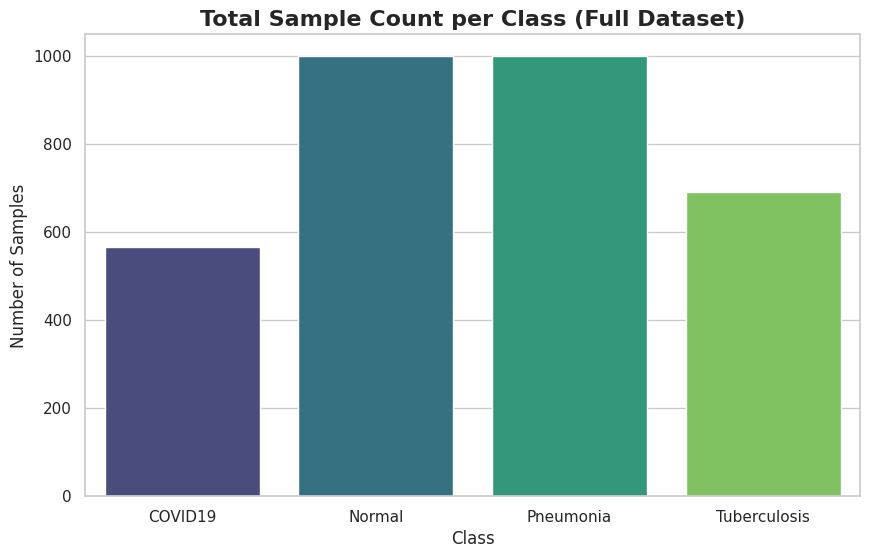

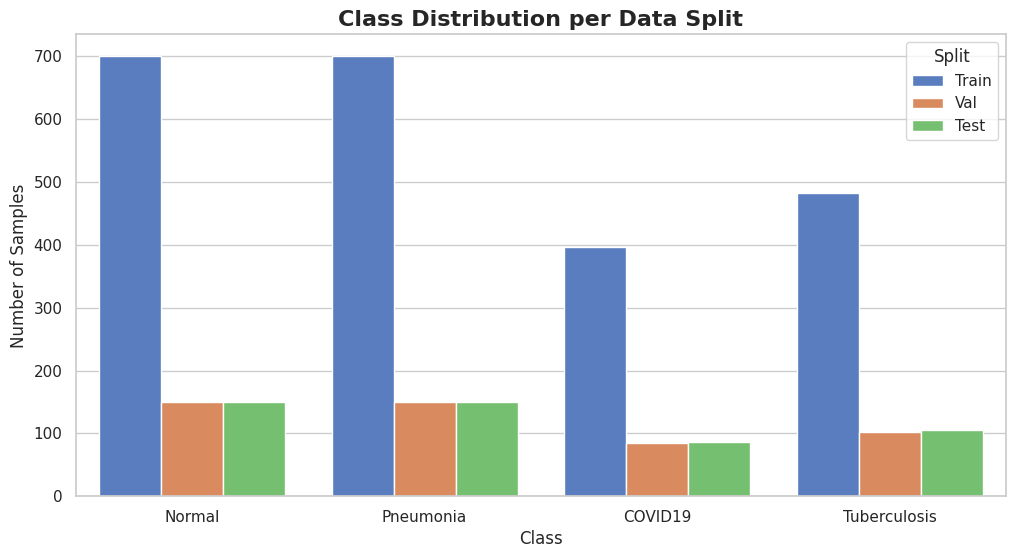

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from PIL import Image
import random

# Set consistent style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 16, 'axes.labelsize': 12})

# --- 1. Class Distribution (Full Dataset & Splits) ---
print("Generating distribution charts...")
splits = ['train', 'val', 'test']
classes = ["Normal", "Pneumonia", "COVID19", "Tuberculosis"]
data_counts = []

for split in splits:
    for cls in classes:
        path = f"{DRIVE_PATH}/dataset/{split}/{cls}"
        count = len([f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        data_counts.append({'Split': split.capitalize(), 'Class': cls, 'Count': count})

df_dist = pd.DataFrame(data_counts)

# Plot A: Total distribution
plt.figure(figsize=(10, 6))
total_counts = df_dist.groupby('Class')['Count'].sum().reset_index()
sns.barplot(data=total_counts, x='Class', y='Count', hue='Class', palette='viridis', legend=False)
plt.title("Total Sample Count per Class (Full Dataset)", fontweight='bold')
plt.ylabel("Number of Samples")
plt.savefig(f"{DRIVE_PATH}/plots/total_class_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

# Plot B: Split distribution
plt.figure(figsize=(12, 6))
sns.barplot(data=df_dist, x='Class', y='Count', hue='Split')
plt.title("Class Distribution per Data Split", fontweight='bold')
plt.ylabel("Number of Samples")
plt.savefig(f"{DRIVE_PATH}/plots/split_class_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

Generating sample image grid...


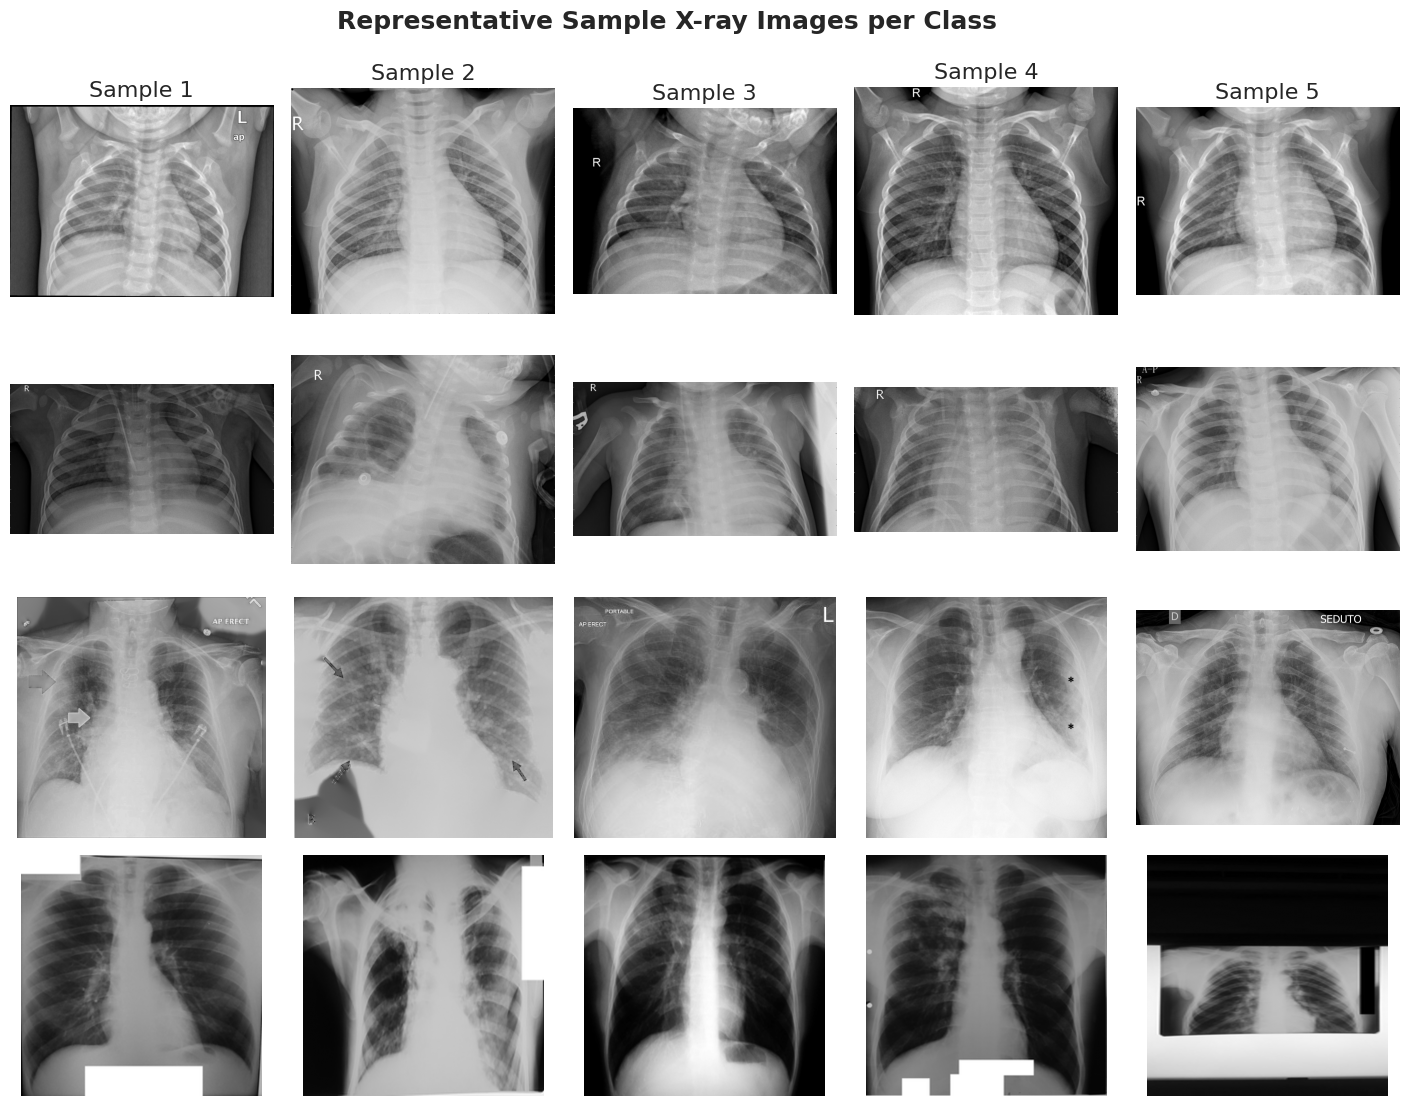

In [ ]:
# --- 2. Grid of Sample X-ray Images ---
print("Generating sample image grid...")

n_samples = 5
fig, axes = plt.subplots(len(classes), n_samples, figsize=(15, 12))

for i, cls in enumerate(classes):
    class_path = f"{DRIVE_PATH}/dataset/train/{cls}"
    img_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    selected = random.sample(img_files, n_samples)

    for j, img_name in enumerate(selected):
        img = Image.open(os.path.join(class_path, img_name)).convert('L')
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(cls, rotation=0, size='large', labelpad=60, fontweight='bold')
        if i == 0:
            axes[i, j].set_title(f"Sample {j+1}")

plt.suptitle("Representative Sample X-ray Images per Class", fontsize=18, fontweight='bold', y=0.95)
plt.tight_layout(rect=[0.05, 0.03, 1, 0.95])
plt.savefig(f"{DRIVE_PATH}/plots/sample_grid_classes.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# SECTION 7: IMPORT TRAINING LIBRARIES
# ============================================
print("\n📚 SECTION 7: Loading Training Libraries...")
print("-"*80)

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler, ConcatDataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
import timm
from torch.cuda.amp import autocast, GradScaler
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Libraries loaded!")
print(f"📱 Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")



📚 SECTION 7: Loading Training Libraries...
--------------------------------------------------------------------------------
✅ Libraries loaded!
📱 Device: cuda
   GPU: Tesla T4


In [ ]:
# HELPER FUNCTION: PLOT TRAINING HISTORY
# ============================================
def plot_training_history(history, model_name, save_path):
    """Plot training and validation loss/accuracy curves"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    epochs = range(1, len(history['train_loss']) + 1)

    # Loss plot
    ax1.plot(epochs, history['train_loss'], 'b-o', label='Training Loss', linewidth=2, markersize=6)
    ax1.plot(epochs, history['val_loss'], 'r-s', label='Validation Loss', linewidth=2, markersize=6)
    ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
    ax1.set_title(f'{model_name} - Training and Validation Loss', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)

    # Accuracy plot
    ax2.plot(epochs, history['train_acc'], 'b-o', label='Training Accuracy', linewidth=2, markersize=6)
    ax2.plot(epochs, history['val_acc'], 'r-s', label='Validation Accuracy', linewidth=2, markersize=6)
    ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax2.set_title(f'{model_name} - Training and Validation Accuracy', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"  ✓ Training curves saved: {save_path}")

# ============================================
# HELPER FUNCTION: PLOT CONFUSION MATRIX
# ============================================
def plot_confusion_matrix(y_true, y_pred, class_names, model_name, save_path):
    """Plot confusion matrix with counts and percentages"""
    cm = confusion_matrix(y_true, y_pred)

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    # Confusion Matrix with counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'}, ax=ax1, annot_kws={"size": 12})
    ax1.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax1.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax1.set_title(f'{model_name} - Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

    # Normalized confusion matrix (percentages)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Percentage'}, ax=ax2, annot_kws={"size": 12})
    ax2.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax2.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax2.set_title(f'{model_name} - Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"  ✓ Confusion matrix saved: {save_path}")

    return cm

# ============================================
# HELPER FUNCTION: PLOT PER-CLASS METRICS
# ============================================
def plot_per_class_metrics(y_true, y_pred, class_names, model_name, save_path):
    """Plot per-class precision, recall, and F1-score"""
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred)

    x = np.arange(len(class_names))
    width = 0.25

    fig, ax = plt.subplots(figsize=(12, 6))

    bars1 = ax.bar(x - width, precision, width, label='Precision', color='#3498db')
    bars2 = ax.bar(x, recall, width, label='Recall', color='#e74c3c')
    bars3 = ax.bar(x + width, f1, width, label='F1-Score', color='#2ecc71')

    ax.set_xlabel('Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title(f'{model_name} - Per-Class Metrics', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 1.1])

    # Add value labels on bars
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}',
                   ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"  ✓ Per-class metrics saved: {save_path}")



🏋️ SECTION 8: TRAINING ADVANCED RESNET-18
  🖥️  Device      : cuda
  🔧  GPU         : Tesla T4
  🔧  CUDA        : 12.8
  🔧  PyTorch     : 2.10.0+cu128

🎯 Starting Advanced ResNet-18 training...

  📂 Classes (4): ['COVID19', 'Normal', 'Pneumonia', 'Tuberculosis']
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s] 



📈 Training Progress:
 Epoch | Train Loss | Train Acc | Val Loss |  Val Acc | Status
---------------------------------------------------------------------------
  [ 1/40] |     0.9402 |    0.6695 |   0.5479 |   0.9117 | ⭐ NEW BEST
  [ 2/40] |     0.6448 |    0.8596 |   0.5515 |   0.9281 | ⭐ NEW BEST
  [ 3/40] |     0.5825 |    0.9045 |   0.4971 |   0.9466 | ⭐ NEW BEST
  [ 4/40] |     0.5573 |    0.9062 |   0.4807 |   0.9528 | ⭐ NEW BEST
  [ 5/40] |     0.5463 |    0.9155 |   0.4758 |   0.9446 | patience 1/10
  [ 6/40] |     0.5546 |    0.9089 |   0.4697 |   0.9528 | patience 2/10
  [ 7/40] |     0.5381 |    0.9243 |   0.4719 |   0.9548 | ⭐ NEW BEST
  [ 8/40] |     0.5230 |    0.9309 |   0.4564 |   0.9610 | ⭐ NEW BEST
  [ 9/40] |     0.5090 |    0.9375 |   0.4685 |   0.9589 | patience 1/10
  [10/40] |     0.4979 |    0.9393 |   0.4579 |   0.9548 | patience 2/10
  [11/40] |     0.4883 |    0.9485 |   0.4566 |   0.9507 | patience 3/10
  [12/40] |     0.4703 |    0.9516 |   0.4612 |   0.95

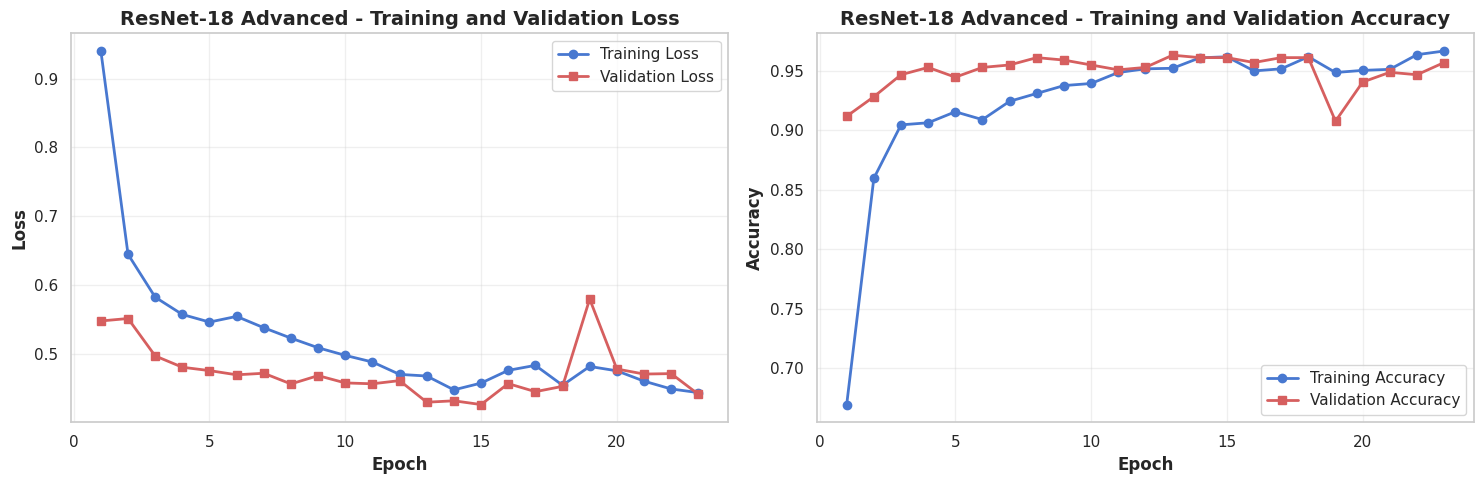

  ✓ Training curves saved: /kaggle/working/ChestXray_Project_XV1/plots/resnet18_training_curves.png

📊 Evaluating ResNet-18 on test set...
✅ ResNet-18 Test Accuracy: 97.76%

📊 Generating evaluation visualizations...


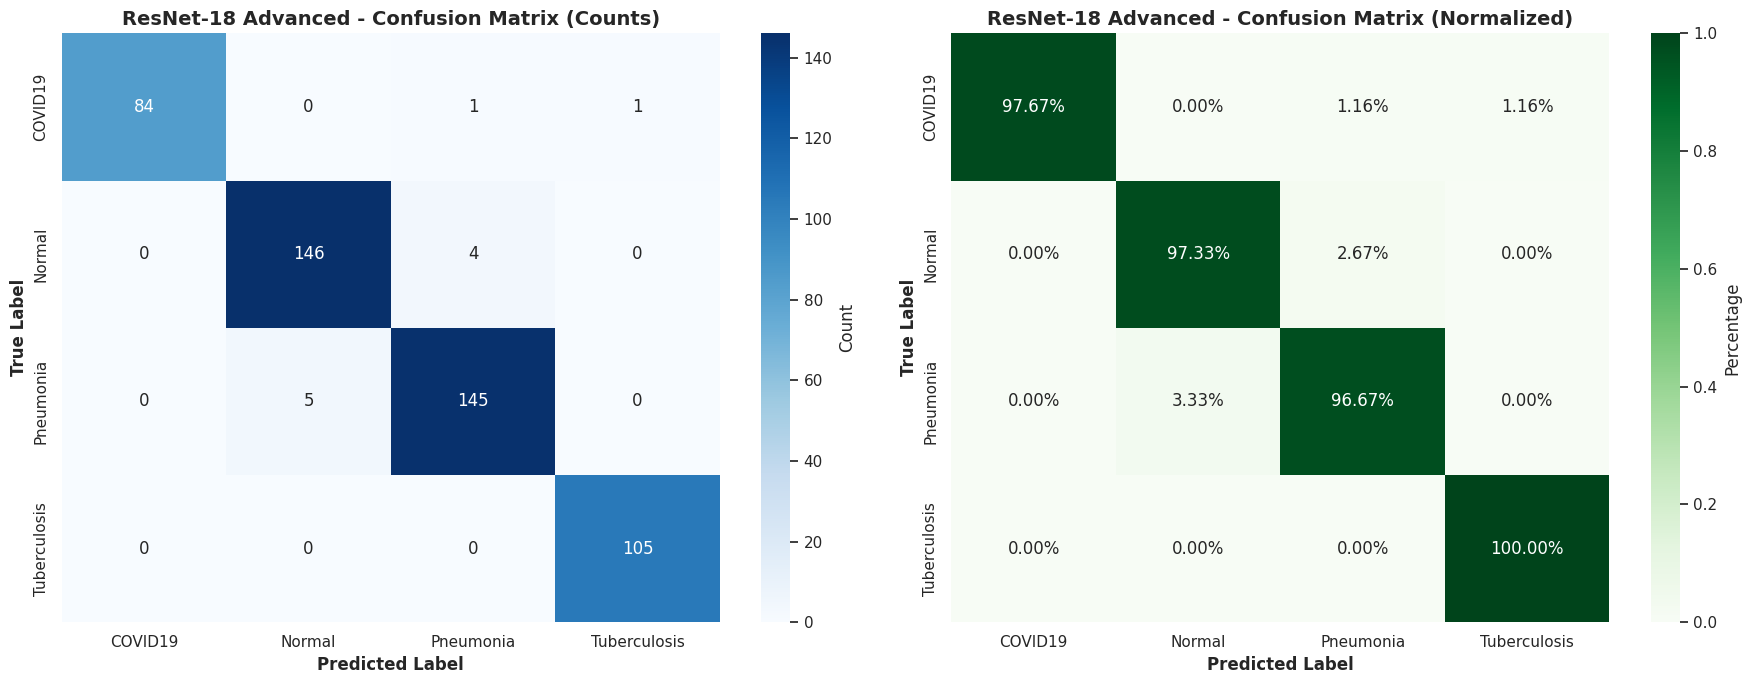

  ✓ Confusion matrix saved: /kaggle/working/ChestXray_Project_XV1/plots/resnet18_confusion_matrix.png


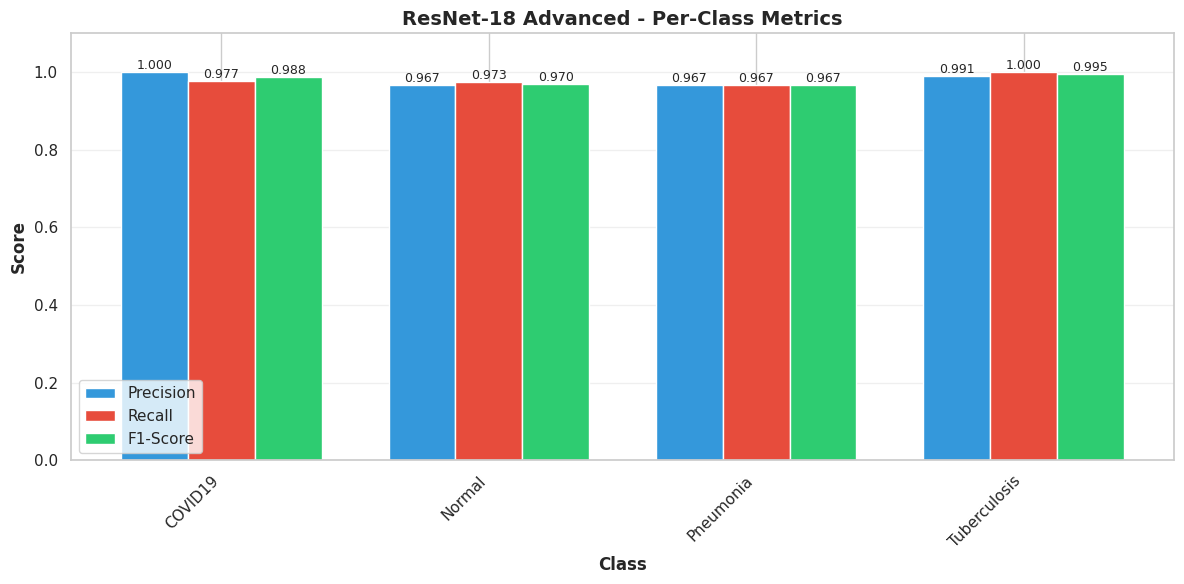

  ✓ Per-class metrics saved: /kaggle/working/ChestXray_Project_XV1/plots/resnet18_per_class_metrics.png

📋 ResNet-18 Classification Report:
              precision    recall  f1-score   support

     COVID19     1.0000    0.9767    0.9882        86
      Normal     0.9669    0.9733    0.9701       150
   Pneumonia     0.9667    0.9667    0.9667       150
Tuberculosis     0.9906    1.0000    0.9953       105

    accuracy                         0.9776       491
   macro avg     0.9810    0.9792    0.9801       491
weighted avg     0.9777    0.9776    0.9776       491

💾 Results saved to: /kaggle/working/ChestXray_Project_XV1/results/resnet18_advanced_results.json


In [ ]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from collections import Counter
from sklearn.metrics import (accuracy_score, classification_report,
                             precision_recall_fscore_support)
import json

# SECTION 8: ADVANCED RESNET-18 TRAINING
# ============================================
print("\n" + "="*80)
print("🏋️ SECTION 8: TRAINING ADVANCED RESNET-18")
print("="*80)

# ── Device setup ──────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"  🖥️  Device      : {device}")
if torch.cuda.is_available():
    print(f"  🔧  GPU         : {torch.cuda.get_device_name(0)}")
    print(f"  🔧  CUDA        : {torch.version.cuda}")
    print(f"  🔧  PyTorch     : {torch.__version__}")
    torch.cuda.empty_cache()
    torch.backends.cudnn.benchmark = True

# ── Check if already trained ──────────────────────────────────────────────────
MODEL_PATH = f"{DRIVE_PATH}/models/best_resnet18_advanced.pth"

if os.path.exists(MODEL_PATH):
    print("\n⏭️  Advanced ResNet-18 already trained! Loading from Drive...")
    load_resnet = True
else:
    load_resnet = False
    print("\n🎯 Starting Advanced ResNet-18 training...")

    # ── Transforms ────────────────────────────────────────────────────────────
    train_transforms_resnet = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(20),
        transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.85, 1.15)),
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
        transforms.RandomGrayscale(p=0.1),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_test_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # ── Datasets ──────────────────────────────────────────────────────────────
    train_dataset = datasets.ImageFolder(f"{OUTPUT_DIR}/train", transform=train_transforms_resnet)
    val_dataset   = datasets.ImageFolder(f"{OUTPUT_DIR}/val",   transform=val_test_transforms)
    test_dataset  = datasets.ImageFolder(f"{OUTPUT_DIR}/test",  transform=val_test_transforms)

    class_names = train_dataset.classes
    num_classes = len(class_names)
    print(f"\n  📂 Classes ({num_classes}): {class_names}")

    # ── Weighted sampler ──────────────────────────────────────────────────────
    class_counts   = Counter([label for _, label in train_dataset.samples])
    class_weights  = {cls: 1.0 / count for cls, count in class_counts.items()}
    sample_weights = [class_weights[label] for _, label in train_dataset.samples]
    sampler        = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    # ── Loaders ───────────────────────────────────────────────────────────────
    train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler,
                              num_workers=2, drop_last=True)   # drop_last fixes BatchNorm1d crash
    val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
    test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

    # ── Model ─────────────────────────────────────────────────────────────────
    class AdvancedResNet(nn.Module):
        def __init__(self, num_classes, dropout=0.5):
            super().__init__()
            self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
            num_features  = self.backbone.fc.in_features
            self.backbone.fc = nn.Sequential(
                nn.Dropout(p=dropout),
                nn.Linear(num_features, 512),
                nn.ReLU(),
                nn.BatchNorm1d(512),
                nn.Dropout(p=dropout * 0.5),
                nn.Linear(512, num_classes)
            )

        def forward(self, x):
            return self.backbone(x)

    model_resnet = AdvancedResNet(num_classes=num_classes, dropout=0.5).to(device)

    # ── Label smoothing loss ──────────────────────────────────────────────────
    class LabelSmoothingCE(nn.Module):
        def __init__(self, smoothing=0.1):
            super().__init__()
            self.smoothing = smoothing

        def forward(self, pred, target):
            confidence = 1.0 - self.smoothing
            log_probs  = torch.nn.functional.log_softmax(pred, dim=1)
            nll_loss   = -log_probs.gather(dim=1, index=target.unsqueeze(1)).squeeze(1)
            smooth_loss = -log_probs.mean(dim=1)
            return (confidence * nll_loss + self.smoothing * smooth_loss).mean()

    criterion = LabelSmoothingCE(smoothing=0.1)
    optimizer = optim.AdamW(model_resnet.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-7)

    # ── AMP scaler (fixed deprecation) ────────────────────────────────────────
    scaler = torch.amp.GradScaler('cuda')

    # ── Train one epoch ───────────────────────────────────────────────────────
    def train_epoch(model, loader, criterion, optimizer):
        model.train()
        running_loss = 0.0
        correct = 0
        total   = 0

        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss    = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct  += (preds == labels).sum().item()
            total    += labels.size(0)

        return running_loss / total, correct / total

    # ── Validate ──────────────────────────────────────────────────────────────
    def validate(model, loader, criterion):
        model.eval()
        running_loss = 0.0
        correct = 0
        total   = 0

        with torch.no_grad():
            for images, labels in loader:
                images, labels = images.to(device), labels.to(device)

                with torch.amp.autocast('cuda'):
                    outputs = model(images)
                    loss    = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                correct  += (preds == labels).sum().item()
                total    += labels.size(0)

        return running_loss / total, correct / total

    # ── Training loop ─────────────────────────────────────────────────────────
    best_val_acc    = 0.0
    patience_counter = 0
    history_resnet  = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    os.makedirs(f"{DRIVE_PATH}/models", exist_ok=True)

    print("\n📈 Training Progress:")
    print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>8} | Status")
    print("-" * 75)

    for epoch in range(40):
        train_loss, train_acc = train_epoch(model_resnet, train_loader, criterion, optimizer)
        val_loss,   val_acc   = validate(model_resnet, val_loader, criterion)
        scheduler.step()

        history_resnet['train_loss'].append(train_loss)
        history_resnet['train_acc'].append(train_acc)
        history_resnet['val_loss'].append(val_loss)
        history_resnet['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc     = val_acc
            patience_counter = 0
            torch.save(model_resnet.state_dict(), MODEL_PATH)
            status = "⭐ NEW BEST"
        else:
            patience_counter += 1
            status = f"patience {patience_counter}/10"

        print(f"  [{epoch+1:2d}/40] | {train_loss:10.4f} | {train_acc:9.4f} | "
              f"{val_loss:8.4f} | {val_acc:8.4f} | {status}")

        if patience_counter >= 10:
            print(f"\n⏹️  Early stopping at epoch {epoch+1}")
            break

    print(f"\n✅ Training complete! Best Val Acc: {best_val_acc*100:.2f}%")
    print(f"💾 Model saved to: {MODEL_PATH}")

    # Plot training curves
    print("\n📊 Generating training curves...")
    os.makedirs(f"{DRIVE_PATH}/plots", exist_ok=True)
    plot_training_history(history_resnet, "ResNet-18 Advanced",
                          f"{DRIVE_PATH}/plots/resnet18_training_curves.png")

# ── Model definition (needed for both train & load paths) ─────────────────────
class AdvancedResNet(nn.Module):
    def __init__(self, num_classes, dropout=0.5):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        num_features  = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(p=dropout * 0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

# ── Evaluation setup ──────────────────────────────────────────────────────────
print("\n📊 Evaluating ResNet-18 on test set...")

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset  = datasets.ImageFolder(f"{OUTPUT_DIR}/test", transform=val_test_transforms)
test_loader   = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)
class_names   = test_dataset.classes
num_classes   = len(class_names)

model_resnet  = AdvancedResNet(num_classes=num_classes, dropout=0.5).to(device)
model_resnet.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model_resnet.eval()

# ── Inference ─────────────────────────────────────────────────────────────────
y_true_resnet, y_pred_resnet = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model_resnet(images)
        _, preds = torch.max(outputs, 1)
        y_true_resnet.extend(labels.numpy())
        y_pred_resnet.extend(preds.cpu().numpy())

acc_resnet = accuracy_score(y_true_resnet, y_pred_resnet)
print(f"✅ ResNet-18 Test Accuracy: {acc_resnet*100:.2f}%")

# ── Visualizations ────────────────────────────────────────────────────────────
print("\n📊 Generating evaluation visualizations...")
os.makedirs(f"{DRIVE_PATH}/plots",   exist_ok=True)
os.makedirs(f"{DRIVE_PATH}/results", exist_ok=True)

cm_resnet = plot_confusion_matrix(y_true_resnet, y_pred_resnet, class_names,
                                  "ResNet-18 Advanced",
                                  f"{DRIVE_PATH}/plots/resnet18_confusion_matrix.png")
plot_per_class_metrics(y_true_resnet, y_pred_resnet, class_names,
                       "ResNet-18 Advanced",
                       f"{DRIVE_PATH}/plots/resnet18_per_class_metrics.png")

# ── Classification report ─────────────────────────────────────────────────────
print("\n📋 ResNet-18 Classification Report:")
print(classification_report(y_true_resnet, y_pred_resnet, target_names=class_names, digits=4))

# ── Save results ──────────────────────────────────────────────────────────────
precision_resnet, recall_resnet, f1_resnet, support_resnet = \
    precision_recall_fscore_support(y_true_resnet, y_pred_resnet)

results_resnet = {
    'model'           : 'Advanced ResNet-18',
    'test_accuracy'   : acc_resnet,
    'class_names'     : class_names,
    'confusion_matrix': cm_resnet.tolist(),
    'precision'       : precision_resnet.tolist(),
    'recall'          : recall_resnet.tolist(),
    'f1'              : f1_resnet.tolist(),
    'support'         : support_resnet.tolist()
}

if not load_resnet:
    results_resnet['history'] = history_resnet

with open(f"{DRIVE_PATH}/results/resnet18_advanced_results.json", 'w') as f:
    json.dump(results_resnet, f, indent=2)

print(f"💾 Results saved to: {DRIVE_PATH}/results/resnet18_advanced_results.json")


🏋️ SECTION 9: TRAINING ADVANCED ViT
  📂 Classes (4): ['COVID19', 'Normal', 'Pneumonia', 'Tuberculosis']

🎯 Starting Advanced ViT training with expanded dataset...
  ✓ Expanded training set: 9116 images (4x)


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]


📈 Training Progress:
 Epoch | Train Loss | Train Acc | Val Loss |  Val Acc | Status
---------------------------------------------------------------------------
  [ 1/50] |     0.6167 |    0.9245 |   0.5350 |   0.9651 | ⭐ NEW BEST
  [ 2/50] |     0.5787 |    0.9464 |   0.5291 |   0.9795 | ⭐ NEW BEST
  [ 3/50] |     0.5845 |    0.9429 |   0.5536 |   0.9610 | patience 1/15
  [ 4/50] |     0.5952 |    0.9378 |   0.5780 |   0.9528 | patience 2/15
  [ 5/50] |     0.5978 |    0.9341 |   0.5865 |   0.9384 | patience 3/15
  [ 6/50] |     0.6015 |    0.9302 |   0.5608 |   0.9507 | patience 4/15
  [ 7/50] |     0.5911 |    0.9358 |   0.5441 |   0.9589 | patience 5/15
  [ 8/50] |     0.5766 |    0.9416 |   0.5650 |   0.9528 | patience 6/15
  [ 9/50] |     0.5777 |    0.9412 |   0.5855 |   0.9343 | patience 7/15
  [10/50] |     0.5665 |    0.9518 |   0.5750 |   0.9548 | patience 8/15
  [11/50] |     0.5678 |    0.9493 |   0.5993 |   0.9384 | patience 9/15
  [12/50] |     0.5666 |    0.9479 |   0.5

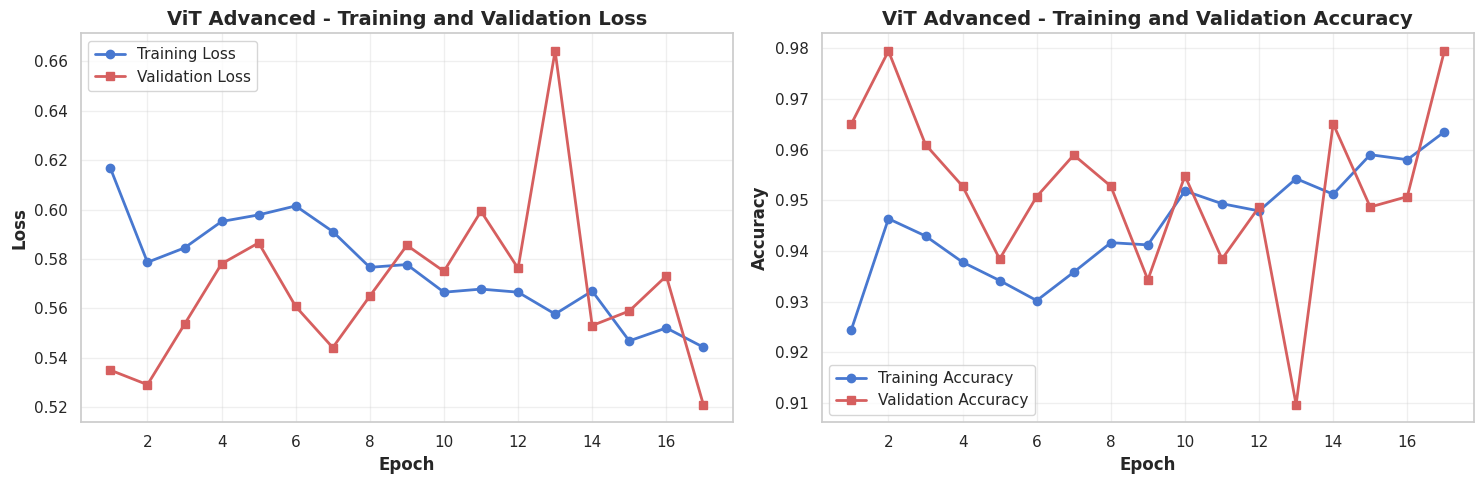

  ✓ Training curves saved: /kaggle/working/ChestXray_Project_XV1/plots/vit_training_curves.png

📊 Evaluating ViT on test set...
✅ ViT Test Accuracy: 96.54%

📊 Generating ViT evaluation visualizations...


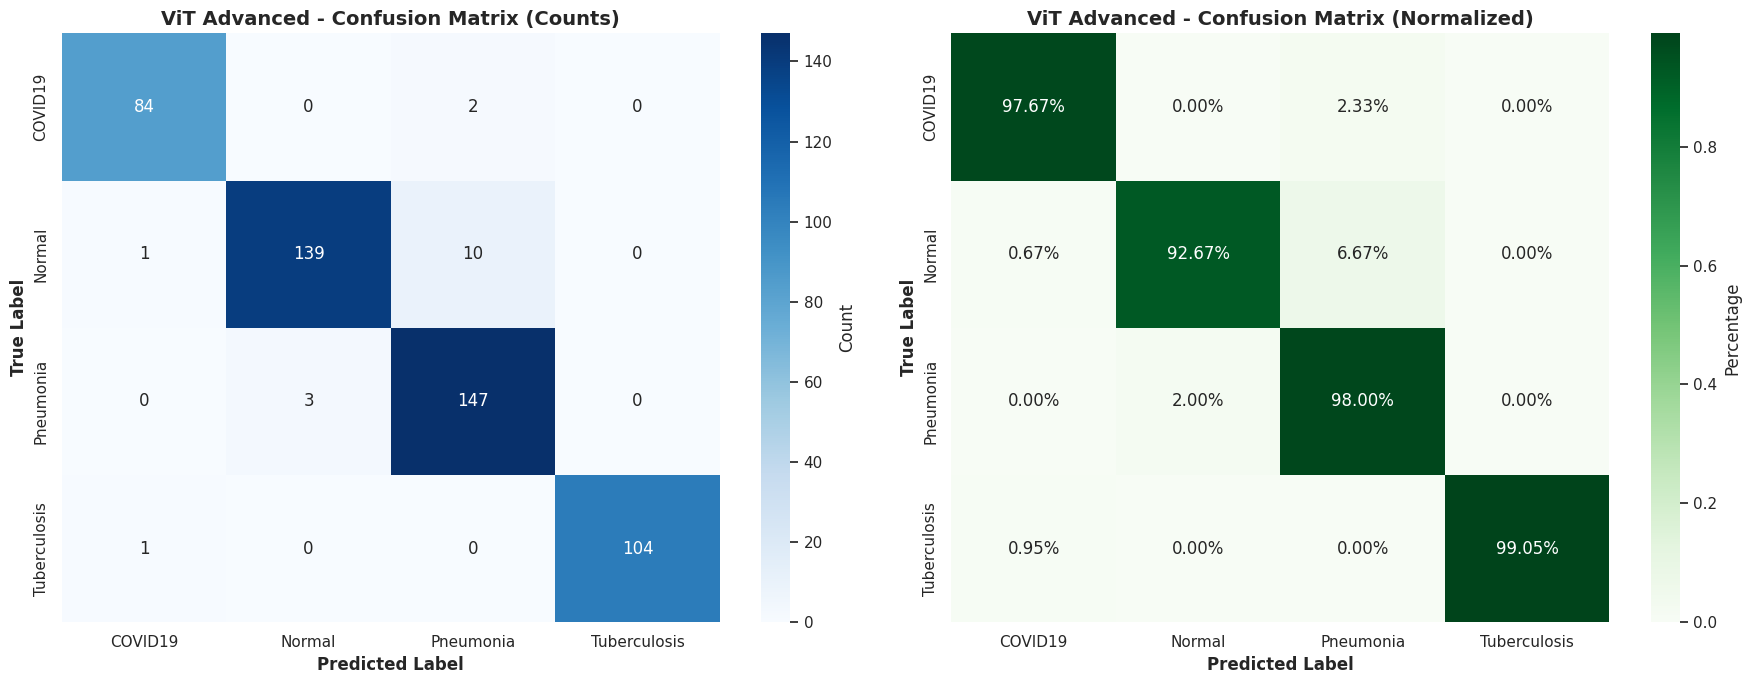

  ✓ Confusion matrix saved: /kaggle/working/ChestXray_Project_XV1/plots/vit_confusion_matrix.png


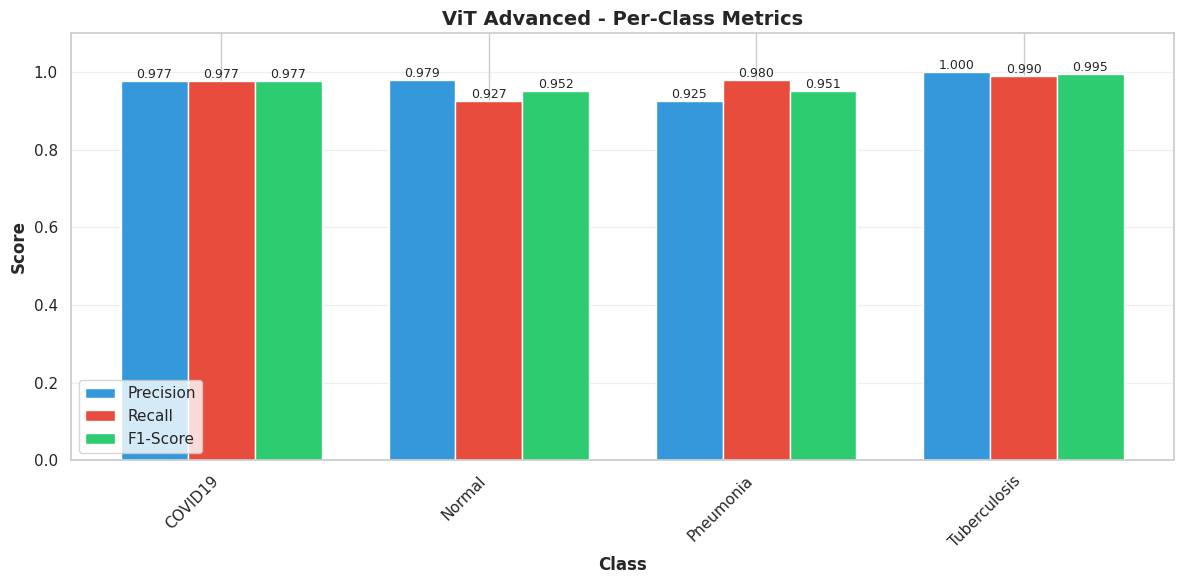

  ✓ Per-class metrics saved: /kaggle/working/ChestXray_Project_XV1/plots/vit_per_class_metrics.png

📋 ViT Classification Report:
              precision    recall  f1-score   support

     COVID19     0.9767    0.9767    0.9767        86
      Normal     0.9789    0.9267    0.9521       150
   Pneumonia     0.9245    0.9800    0.9515       150
Tuberculosis     1.0000    0.9905    0.9952       105

    accuracy                         0.9654       491
   macro avg     0.9700    0.9685    0.9689       491
weighted avg     0.9664    0.9654    0.9654       491

💾 ViT results saved to: /kaggle/working/ChestXray_Project_XV1/results/vit_advanced_results.json


In [ ]:
# ============================================
# SECTION 9: ADVANCED ViT TRAINING
# ============================================
print("\n" + "="*80)
print("🏋️ SECTION 9: TRAINING ADVANCED ViT")
print("="*80)

MODEL_PATH_VIT = f"{DRIVE_PATH}/models/best_vit_advanced.pth"

# ── num_classes from test_dataset (always available after Section 8) ──────────
test_dataset_vit = datasets.ImageFolder(
    f"{OUTPUT_DIR}/test",
    transform=transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
)
class_names  = test_dataset_vit.classes
num_classes  = len(class_names)
test_loader_vit = DataLoader(test_dataset_vit, batch_size=24, shuffle=False, num_workers=2)

print(f"  📂 Classes ({num_classes}): {class_names}")

# ── Check if already trained ──────────────────────────────────────────────────
if os.path.exists(MODEL_PATH_VIT):
    print("\n⏭️  Advanced ViT already trained! Loading from Drive...")
    load_vit = True
else:
    load_vit = False
    print("\n🎯 Starting Advanced ViT training with expanded dataset...")

    # ── 4x augmentation pipelines ─────────────────────────────────────────────
    aug_pipelines = [
        transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(25),
            transforms.RandomAffine(degrees=0, translate=(0.2, 0.2)),
            transforms.ColorJitter(brightness=0.4, contrast=0.4),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ]),
        transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.3),
            transforms.GaussianBlur(3),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ]),
        transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
            transforms.RandomRotation(15),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ]),
        transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ToTensor(),
            transforms.RandomErasing(p=0.3),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])
    ]

    # ── Expanded dataset ──────────────────────────────────────────────────────
    train_datasets_vit = [
        datasets.ImageFolder(f"{OUTPUT_DIR}/train", transform=aug)
        for aug in aug_pipelines
    ]
    expanded_train = ConcatDataset(train_datasets_vit)
    print(f"  ✓ Expanded training set: {len(expanded_train)} images (4x)")

    # ── Weighted sampler ──────────────────────────────────────────────────────
    all_labels = []
    for ds in train_datasets_vit:
        all_labels.extend([label for _, label in ds.samples])

    class_counts_vit   = Counter(all_labels)
    class_weights_vit  = {cls: 1.0 / count for cls, count in class_counts_vit.items()}
    sample_weights_vit = [class_weights_vit[label] for label in all_labels]
    sampler_vit        = WeightedRandomSampler(sample_weights_vit, len(sample_weights_vit), replacement=True)

    # ── Loaders ───────────────────────────────────────────────────────────────
    train_loader_vit = DataLoader(expanded_train, batch_size=24, sampler=sampler_vit,
                                  num_workers=2, drop_last=True)  # drop_last fixes BatchNorm crash

    val_dataset_vit = datasets.ImageFolder(
        f"{OUTPUT_DIR}/val",
        transform=transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])
    )
    val_loader_vit = DataLoader(val_dataset_vit, batch_size=24, shuffle=False, num_workers=2)

    # ── ViT-Small model ───────────────────────────────────────────────────────
    model_vit      = timm.create_model('vit_small_patch16_224', pretrained=True,
                                       num_classes=num_classes).to(device)
    criterion_vit  = LabelSmoothingCE(smoothing=0.15)
    optimizer_vit  = optim.AdamW(model_vit.parameters(), lr=3e-4, weight_decay=0.05)

    # ── Warmup + cosine scheduler ─────────────────────────────────────────────
    from torch.optim.lr_scheduler import LambdaLR
    import numpy as np

    def warmup_cosine(epoch):
        if epoch < 5:
            return (epoch + 1) / 5
        return 0.5 * (1 + np.cos(np.pi * (epoch - 5) / 45))

    scheduler_vit = LambdaLR(optimizer_vit, warmup_cosine)

    # ── AMP scaler (fixed deprecation) ────────────────────────────────────────
    scaler_vit = torch.amp.GradScaler('cuda')

    # ── Training loop ─────────────────────────────────────────────────────────
    best_val_acc_vit     = 0.0
    patience_counter_vit = 0
    history_vit = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    os.makedirs(f"{DRIVE_PATH}/models", exist_ok=True)

    print("\n📈 Training Progress:")
    print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>8} | Status")
    print("-" * 75)

    for epoch in range(50):
        # ── Train ─────────────────────────────────────────────────────────────
        model_vit.train()
        running_loss = 0.0
        correct = 0
        total   = 0

        for images, labels in train_loader_vit:
            images, labels = images.to(device), labels.to(device)
            optimizer_vit.zero_grad()

            with torch.amp.autocast('cuda'):
                outputs = model_vit(images)
                loss    = criterion_vit(outputs, labels)

            scaler_vit.scale(loss).backward()
            scaler_vit.unscale_(optimizer_vit)
            torch.nn.utils.clip_grad_norm_(model_vit.parameters(), max_norm=1.0)
            scaler_vit.step(optimizer_vit)
            scaler_vit.update()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct  += (preds == labels).sum().item()
            total    += labels.size(0)

        train_loss_vit = running_loss / total
        train_acc_vit  = correct / total

        # ── Validate ──────────────────────────────────────────────────────────
        val_loss_vit, val_acc_vit = validate(model_vit, val_loader_vit, criterion_vit)
        scheduler_vit.step()

        history_vit['train_loss'].append(train_loss_vit)
        history_vit['train_acc'].append(train_acc_vit)
        history_vit['val_loss'].append(val_loss_vit)
        history_vit['val_acc'].append(val_acc_vit)

        if val_acc_vit > best_val_acc_vit:
            best_val_acc_vit     = val_acc_vit
            patience_counter_vit = 0
            torch.save(model_vit.state_dict(), MODEL_PATH_VIT)
            status = "⭐ NEW BEST"
        else:
            patience_counter_vit += 1
            status = f"patience {patience_counter_vit}/15"

        print(f"  [{epoch+1:2d}/50] | {train_loss_vit:10.4f} | {train_acc_vit:9.4f} | "
              f"{val_loss_vit:8.4f} | {val_acc_vit:8.4f} | {status}")

        if patience_counter_vit >= 15:
            print(f"\n⏹️  Early stopping at epoch {epoch+1}")
            break

    print(f"\n✅ ViT training complete! Best Val Acc: {best_val_acc_vit*100:.2f}%")
    print(f"💾 Model saved to: {MODEL_PATH_VIT}")

    os.makedirs(f"{DRIVE_PATH}/plots", exist_ok=True)
    plot_training_history(history_vit, "ViT Advanced",
                          f"{DRIVE_PATH}/plots/vit_training_curves.png")

# ── Evaluation ────────────────────────────────────────────────────────────────
print("\n📊 Evaluating ViT on test set...")

model_vit = timm.create_model('vit_small_patch16_224', pretrained=False,
                               num_classes=num_classes).to(device)
model_vit.load_state_dict(torch.load(MODEL_PATH_VIT, map_location=device))
model_vit.eval()

y_true_vit, y_pred_vit = [], []
with torch.no_grad():
    for images, labels in test_loader_vit:
        images  = images.to(device)
        outputs = model_vit(images)
        _, preds = torch.max(outputs, 1)
        y_true_vit.extend(labels.numpy())
        y_pred_vit.extend(preds.cpu().numpy())

acc_vit = accuracy_score(y_true_vit, y_pred_vit)
print(f"✅ ViT Test Accuracy: {acc_vit*100:.2f}%")

# ── Visualizations ────────────────────────────────────────────────────────────
print("\n📊 Generating ViT evaluation visualizations...")
os.makedirs(f"{DRIVE_PATH}/plots",   exist_ok=True)
os.makedirs(f"{DRIVE_PATH}/results", exist_ok=True)

cm_vit = plot_confusion_matrix(y_true_vit, y_pred_vit, class_names,
                                "ViT Advanced",
                                f"{DRIVE_PATH}/plots/vit_confusion_matrix.png")
plot_per_class_metrics(y_true_vit, y_pred_vit, class_names,
                       "ViT Advanced",
                       f"{DRIVE_PATH}/plots/vit_per_class_metrics.png")

print("\n📋 ViT Classification Report:")
print(classification_report(y_true_vit, y_pred_vit, target_names=class_names, digits=4))

# ── Save results ──────────────────────────────────────────────────────────────
precision_vit, recall_vit, f1_vit, support_vit = \
    precision_recall_fscore_support(y_true_vit, y_pred_vit)

results_vit = {
    'model'            : 'Advanced ViT-Small',
    'dataset_expansion': '4x',
    'test_accuracy'    : acc_vit,
    'class_names'      : class_names,
    'confusion_matrix' : cm_vit.tolist(),
    'precision'        : precision_vit.tolist(),
    'recall'           : recall_vit.tolist(),
    'f1'               : f1_vit.tolist(),
    'support'          : support_vit.tolist()
}

if not load_vit:
    results_vit['history'] = history_vit

with open(f"{DRIVE_PATH}/results/vit_advanced_results.json", 'w') as f:
    json.dump(results_vit, f, indent=2)

print(f"💾 ViT results saved to: {DRIVE_PATH}/results/vit_advanced_results.json")


🏋️ SECTION 10: CREATING ENSEMBLE MODEL
  📂 Classes     : ['COVID19', 'Normal', 'Pneumonia', 'Tuberculosis']
  🔢 Batch size  : 32 (both loaders matched)
  🖼️  Test images : 491

🔍 Testing different ensemble weight combinations...
  Ensemble [ResNet:0.3 / ViT:0.7]: 96.54%
  Ensemble [ResNet:0.4 / ViT:0.6]: 96.74%
  Ensemble [ResNet:0.5 / ViT:0.5]: 97.35%
  Ensemble [ResNet:0.6 / ViT:0.4]: 97.76%
  Ensemble [ResNet:0.7 / ViT:0.3]: 98.17%

✅ Best Ensemble: [ResNet:0.7 / ViT:0.3] → 98.17%

📊 Generating Ensemble visualizations...


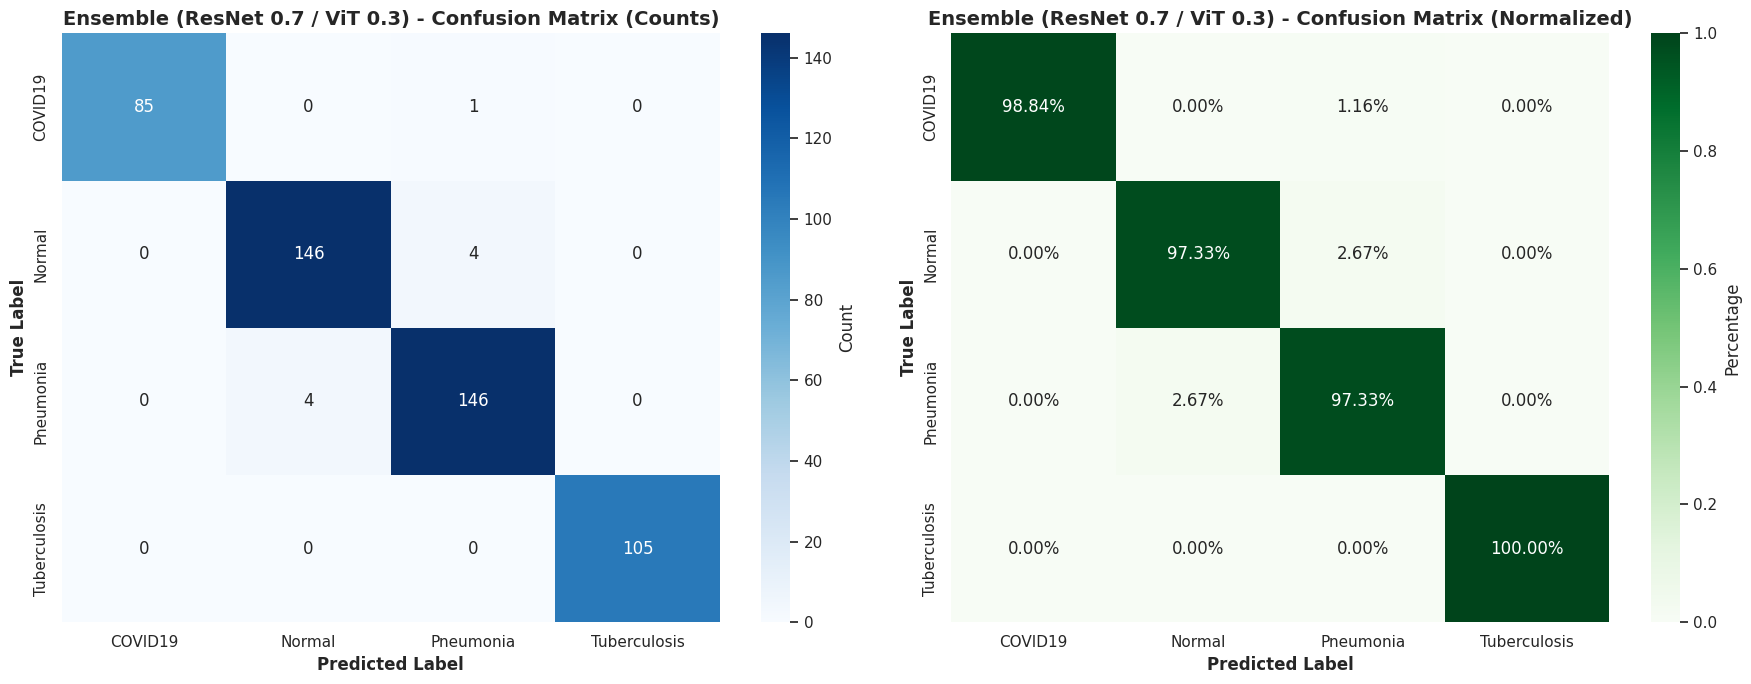

  ✓ Confusion matrix saved: /kaggle/working/ChestXray_Project_XV1/plots/ensemble_confusion_matrix.png


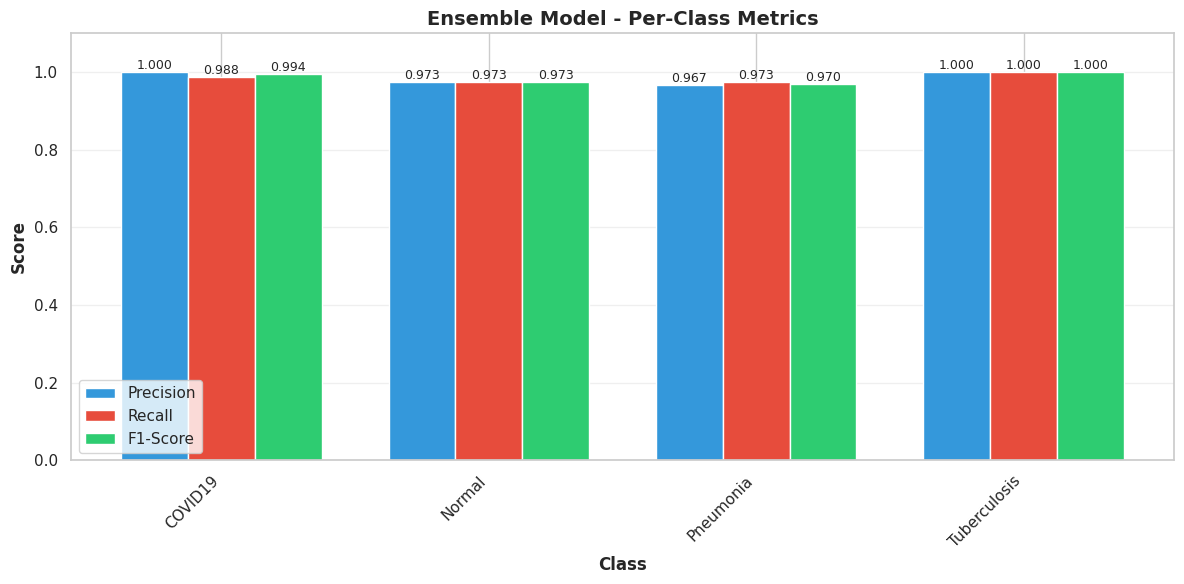

  ✓ Per-class metrics saved: /kaggle/working/ChestXray_Project_XV1/plots/ensemble_per_class_metrics.png

📋 Ensemble Classification Report:
              precision    recall  f1-score   support

     COVID19     1.0000    0.9884    0.9942        86
      Normal     0.9733    0.9733    0.9733       150
   Pneumonia     0.9669    0.9733    0.9701       150
Tuberculosis     1.0000    1.0000    1.0000       105

    accuracy                         0.9817       491
   macro avg     0.9851    0.9838    0.9844       491
weighted avg     0.9817    0.9817    0.9817       491



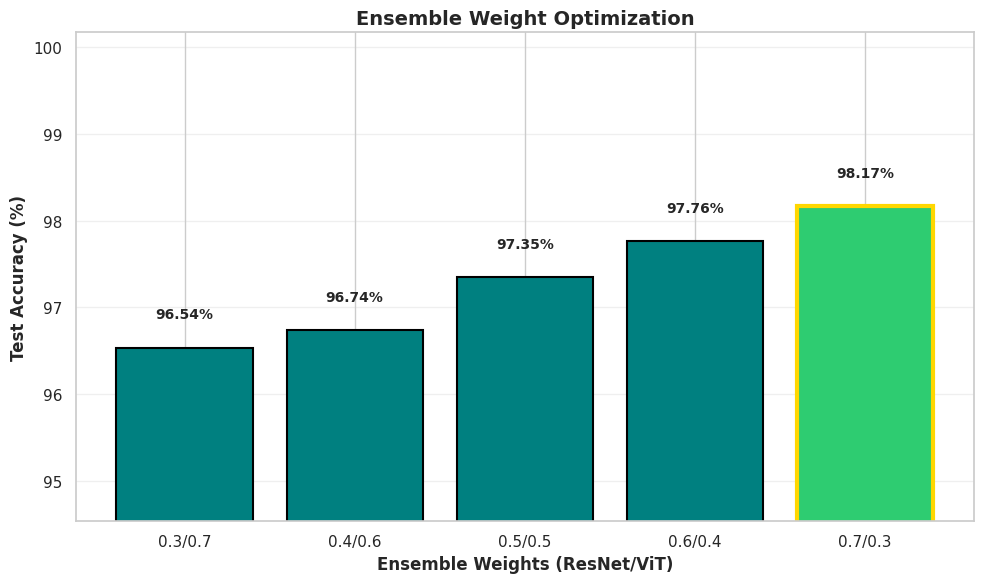

  ✓ Ensemble weight comparison saved
💾 Ensemble results saved to: /kaggle/working/ChestXray_Project_XV1/results/ensemble_results.json


In [ ]:
# SECTION 10: ENSEMBLE MODEL
# ============================================
print("\n" + "="*80)
print("🏋️ SECTION 10: CREATING ENSEMBLE MODEL")
print("="*80)

# ── Ensemble model ────────────────────────────────────────────────────────────
class EnsembleModel(nn.Module):
    def __init__(self, resnet, vit, weights=[0.5, 0.5]):
        super().__init__()
        self.resnet  = resnet
        self.vit     = vit
        self.weights = torch.tensor(weights, device=device)
        self.resnet.eval()
        self.vit.eval()

    def forward(self, x_resnet, x_vit):
        with torch.no_grad():
            resnet_out = torch.softmax(self.resnet(x_resnet), dim=1)
            vit_out    = torch.softmax(self.vit(x_vit),    dim=1)
            return self.weights[0] * resnet_out + self.weights[1] * vit_out

# ── Rebuild test loaders — same batch_size=32, shuffle=False ─────────────────
BATCH_SIZE = 32

test_dataset_resnet = datasets.ImageFolder(
    f"{OUTPUT_DIR}/test",
    transform=transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
)
test_loader_resnet = DataLoader(test_dataset_resnet, batch_size=BATCH_SIZE,
                                shuffle=False, num_workers=2)

test_dataset_vit_ens = datasets.ImageFolder(
    f"{OUTPUT_DIR}/test",
    transform=transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
)
test_loader_vit_ens = DataLoader(test_dataset_vit_ens, batch_size=BATCH_SIZE,
                                 shuffle=False, num_workers=2)

class_names = test_dataset_resnet.classes
print(f"  📂 Classes     : {class_names}")
print(f"  🔢 Batch size  : {BATCH_SIZE} (both loaders matched)")
print(f"  🖼️  Test images : {len(test_dataset_resnet)}")

# ── Weight search ─────────────────────────────────────────────────────────────
print("\n🔍 Testing different ensemble weight combinations...")

best_ensemble_acc = 0.0
best_weights      = [0.5, 0.5]
best_y_true_ens   = []
best_y_pred_ens   = []
weight_results    = []

for w1 in [0.3, 0.4, 0.5, 0.6, 0.7]:
    w2       = round(1.0 - w1, 1)
    ensemble = EnsembleModel(model_resnet, model_vit, weights=[w1, w2]).to(device)

    y_true_ens, y_pred_ens = [], []

    with torch.no_grad():
        for (imgs_resnet, labels), (imgs_vit, _) in zip(test_loader_resnet, test_loader_vit_ens):
            imgs_resnet = imgs_resnet.to(device)
            imgs_vit    = imgs_vit.to(device)

            outputs = ensemble(imgs_resnet, imgs_vit)
            _, preds = torch.max(outputs, 1)
            y_true_ens.extend(labels.numpy())
            y_pred_ens.extend(preds.cpu().numpy())

    acc_ens = accuracy_score(y_true_ens, y_pred_ens)
    weight_results.append((w1, w2, acc_ens))
    print(f"  Ensemble [ResNet:{w1:.1f} / ViT:{w2:.1f}]: {acc_ens*100:.2f}%")

    if acc_ens > best_ensemble_acc:
        best_ensemble_acc = acc_ens
        best_weights      = [w1, w2]
        best_y_true_ens   = y_true_ens.copy()
        best_y_pred_ens   = y_pred_ens.copy()

print(f"\n✅ Best Ensemble: [ResNet:{best_weights[0]:.1f} / ViT:{best_weights[1]:.1f}] "
      f"→ {best_ensemble_acc*100:.2f}%")

# ── Visualizations ────────────────────────────────────────────────────────────
print("\n📊 Generating Ensemble visualizations...")
os.makedirs(f"{DRIVE_PATH}/plots",   exist_ok=True)
os.makedirs(f"{DRIVE_PATH}/results", exist_ok=True)

cm_ensemble = plot_confusion_matrix(
    best_y_true_ens, best_y_pred_ens, class_names,
    f"Ensemble (ResNet {best_weights[0]:.1f} / ViT {best_weights[1]:.1f})",
    f"{DRIVE_PATH}/plots/ensemble_confusion_matrix.png"
)
plot_per_class_metrics(
    best_y_true_ens, best_y_pred_ens, class_names,
    "Ensemble Model",
    f"{DRIVE_PATH}/plots/ensemble_per_class_metrics.png"
)

print("\n📋 Ensemble Classification Report:")
print(classification_report(best_y_true_ens, best_y_pred_ens,
                             target_names=class_names, digits=4))

# ── Weight comparison bar chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
weights_x = [f"{w[0]:.1f}/{w[1]:.1f}" for w in weight_results]
accs      = [w[2] * 100 for w in weight_results]
bars      = ax.bar(weights_x, accs, color='teal', edgecolor='black', linewidth=1.5)

best_idx = accs.index(max(accs))
bars[best_idx].set_color('#2ecc71')
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(3)

ax.set_xlabel('Ensemble Weights (ResNet/ViT)', fontsize=12, fontweight='bold')
ax.set_ylabel('Test Accuracy (%)',             fontsize=12, fontweight='bold')
ax.set_title('Ensemble Weight Optimization',   fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([min(accs) - 2, max(accs) + 2])

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.3,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{DRIVE_PATH}/plots/ensemble_weight_comparison.png", dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Ensemble weight comparison saved")

# ── Save results ──────────────────────────────────────────────────────────────
precision_ens, recall_ens, f1_ens, support_ens = \
    precision_recall_fscore_support(best_y_true_ens, best_y_pred_ens)

results_ensemble = {
    'model'                    : 'Ensemble (ResNet-18 + ViT)',
    'weights'                  : {'resnet': best_weights[0], 'vit': best_weights[1]},
    'test_accuracy'            : best_ensemble_acc,
    'all_weight_configurations': [
        {'weights': [w[0], w[1]], 'accuracy': w[2]} for w in weight_results
    ],
    'class_names'      : class_names,
    'confusion_matrix' : cm_ensemble.tolist(),
    'precision'        : precision_ens.tolist(),
    'recall'           : recall_ens.tolist(),
    'f1'               : f1_ens.tolist(),
    'support'          : support_ens.tolist()
}

with open(f"{DRIVE_PATH}/results/ensemble_results.json", 'w') as f:
    json.dump(results_ensemble, f, indent=2)

print(f"💾 Ensemble results saved to: {DRIVE_PATH}/results/ensemble_results.json")


🎉 FINAL RESULTS & COMPARISON

📂 Loading saved results...
  ✅ ResNet-18 results loaded.
  ✅ ViT results loaded.
  ✅ Ensemble results loaded.


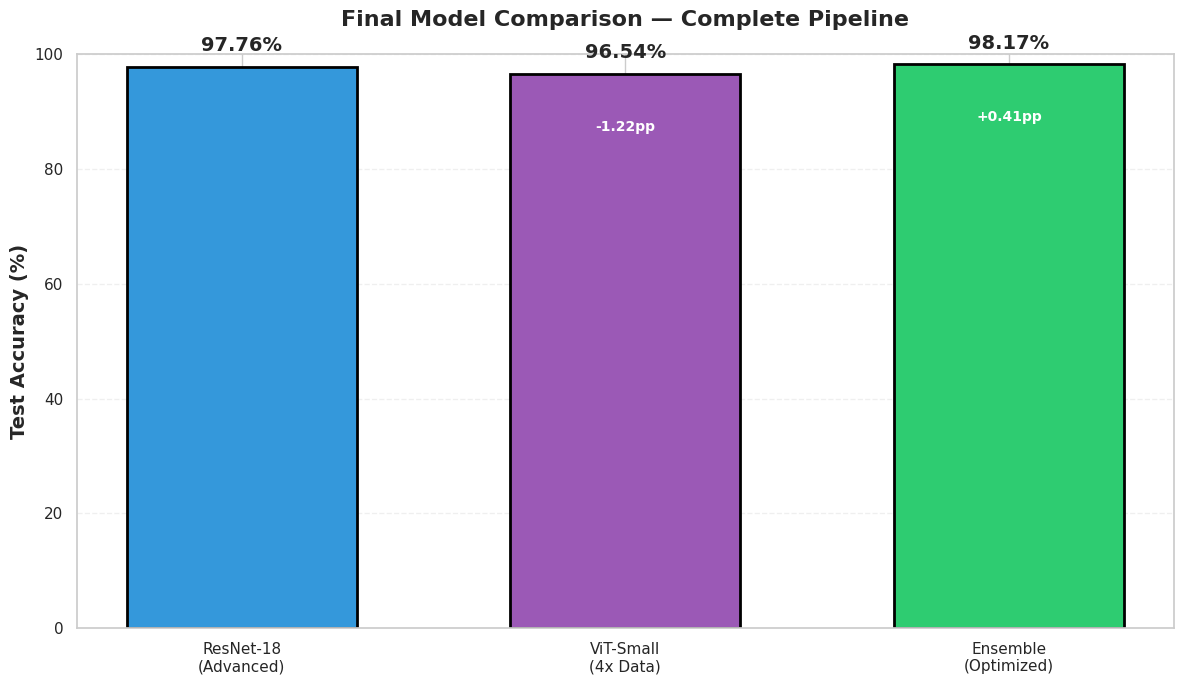

  ✓ Final comparison chart saved

📊 FINAL RESULTS SUMMARY:
Model                       Accuracy   Precision    Recall   F1-Score
--------------------------------------------------------------------------------
  ResNet-18 (Advanced)       97.76%      0.9810    0.9792     0.9801
  ViT-Small (4x Data)        96.54%      0.9700    0.9685     0.9689
  Ensemble (Optimized)       98.17%      0.9851    0.9838     0.9844

📋 Per-Class F1 Scores (Ensemble):
--------------------------------------------------
  COVID19         0.9942  █████████████████████████████
  Normal          0.9733  █████████████████████████████
  Pneumonia       0.9701  █████████████████████████████
  Tuberculosis    1.0000  ██████████████████████████████

💾 ALL FILES SAVED TO: /kaggle/working/ChestXray_Project_XV1/

  📁 models/
     ├── best_resnet18_advanced.pth
     └── best_vit_advanced.pth

  📁 results/
     ├── resnet18_advanced_results.json
     ├── vit_advanced_results.json
     └── ensemble_results.json

  📁 plots

In [ ]:
# SECTION 11: FINAL COMPARISON & SUMMARY
# ============================================
print("\n" + "="*80)
print("🎉 FINAL RESULTS & COMPARISON")
print("="*80)

import numpy as np

# ── Load results from JSON (safe fallback if variables lost between sessions) ──
def load_results(path, label):
    try:
        with open(path, 'r') as f:
            data = json.load(f)
        print(f"  ✅ {label} loaded.")
        return data
    except FileNotFoundError:
        print(f"  ❌ {label} not found at {path} — run the corresponding section first.")
        return None
    except Exception as e:
        print(f"  ⚠️  Error loading {label}: {e}")
        return None

print("\n📂 Loading saved results...")
resnet_data   = load_results(f"{DRIVE_PATH}/results/resnet18_advanced_results.json", "ResNet-18 results")
vit_data      = load_results(f"{DRIVE_PATH}/results/vit_advanced_results.json",      "ViT results")
ensemble_data = load_results(f"{DRIVE_PATH}/results/ensemble_results.json",          "Ensemble results")

if not all([resnet_data, vit_data, ensemble_data]):
    print("\n⛔ Cannot generate final summary — one or more result files missing.")
else:
    # ── Extract metrics ────────────────────────────────────────────────────────
    acc_resnet        = resnet_data['test_accuracy']
    precision_resnet  = np.array(resnet_data['precision'])
    recall_resnet     = np.array(resnet_data['recall'])
    f1_resnet         = np.array(resnet_data['f1'])

    acc_vit           = vit_data['test_accuracy']
    precision_vit     = np.array(vit_data['precision'])
    recall_vit        = np.array(vit_data['recall'])
    f1_vit            = np.array(vit_data['f1'])

    best_ensemble_acc = ensemble_data['test_accuracy']
    precision_ens     = np.array(ensemble_data['precision'])
    recall_ens        = np.array(ensemble_data['recall'])
    f1_ens            = np.array(ensemble_data['f1'])
    best_weights      = [ensemble_data['weights']['resnet'], ensemble_data['weights']['vit']]
    class_names       = ensemble_data['class_names']

    # ── Bar chart comparison ───────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 7))

    model_labels = ['ResNet-18\n(Advanced)', 'ViT-Small\n(4x Data)', 'Ensemble\n(Optimized)']
    accuracies   = [acc_resnet * 100, acc_vit * 100, best_ensemble_acc * 100]
    colors       = ['#3498db', '#9b59b6', '#2ecc71']

    bars = ax.bar(model_labels, accuracies, color=colors, width=0.6,
                  edgecolor='black', linewidth=2)

    ax.set_ylabel('Test Accuracy (%)', fontsize=14, fontweight='bold')
    ax.set_title('Final Model Comparison — Complete Pipeline',
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_ylim([0, 100])
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')

    for i, (bar, acc) in enumerate(zip(bars, accuracies)):
        ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 2,
                f'{acc:.2f}%', ha='center', va='bottom',
                fontsize=14, fontweight='bold')
        if i > 0:
            improvement = acc - accuracies[0]
            sign = '+' if improvement >= 0 else ''
            ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() - 8,
                    f'{sign}{improvement:.2f}pp', ha='center', va='top',
                    fontsize=10, color='white', fontweight='bold')

    plt.tight_layout()
    os.makedirs(f"{DRIVE_PATH}/plots", exist_ok=True)
    plt.savefig(f"{DRIVE_PATH}/plots/final_comparison_all_models.png",
                dpi=300, bbox_inches='tight')
    plt.show()
    print("  ✓ Final comparison chart saved")

    # ── Summary table ──────────────────────────────────────────────────────────
    print(f"\n📊 FINAL RESULTS SUMMARY:")
    print("=" * 80)
    print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>11} {'Recall':>9} {'F1-Score':>10}")
    print("-" * 80)

    rows = [
        ("ResNet-18 (Advanced)", acc_resnet,        precision_resnet, recall_resnet, f1_resnet),
        ("ViT-Small (4x Data)",  acc_vit,            precision_vit,    recall_vit,   f1_vit),
        ("Ensemble (Optimized)", best_ensemble_acc,  precision_ens,    recall_ens,   f1_ens),
    ]

    for name, acc, prec, rec, f1 in rows:
        print(f"  {name:<23} {acc*100:>8.2f}%   {np.mean(prec):>9.4f}   "
              f"{np.mean(rec):>7.4f}   {np.mean(f1):>8.4f}")

    print("=" * 80)

    # ── Per-class F1 breakdown ─────────────────────────────────────────────────
    print(f"\n📋 Per-Class F1 Scores (Ensemble):")
    print("-" * 50)
    for cls, f1_score in zip(class_names, f1_ens):
        bar = "█" * int(f1_score * 30)
        print(f"  {cls:<15} {f1_score:.4f}  {bar}")

    # ── File summary ───────────────────────────────────────────────────────────
    print(f"\n💾 ALL FILES SAVED TO: {DRIVE_PATH}/")
    print(f"\n  📁 models/")
    print(f"     ├── best_resnet18_advanced.pth")
    print(f"     └── best_vit_advanced.pth")
    print(f"\n  📁 results/")
    print(f"     ├── resnet18_advanced_results.json")
    print(f"     ├── vit_advanced_results.json")
    print(f"     └── ensemble_results.json")
    print(f"\n  📁 plots/")
    for plot in [
        "resnet18_training_curves.png", "resnet18_confusion_matrix.png",
        "resnet18_per_class_metrics.png", "vit_training_curves.png",
        "vit_confusion_matrix.png", "vit_per_class_metrics.png",
        "ensemble_confusion_matrix.png", "ensemble_per_class_metrics.png",
        "ensemble_weight_comparison.png", "final_comparison_all_models.png"
    ]:
        print(f"     ├── {plot}")

    print(f"\n⏱️  Total pipeline time: {(time.time() - start_time_total) / 60:.1f} minutes")
    print("\n" + "=" * 80)
    print("✅ COMPLETE PIPELINE FINISHED SUCCESSFULLY!")
    print("=" * 80)
    print(f"\n🎯 Best configuration: ResNet {best_weights[0]:.1f} / ViT {best_weights[1]:.1f}")
    print("🚀 Your chest X-ray classification system is ready for deployment!")

### 📈 Training & Evaluation Visualizations

This section generates detailed training curves (accuracy, loss, learning rate) and final performance metrics for the report.

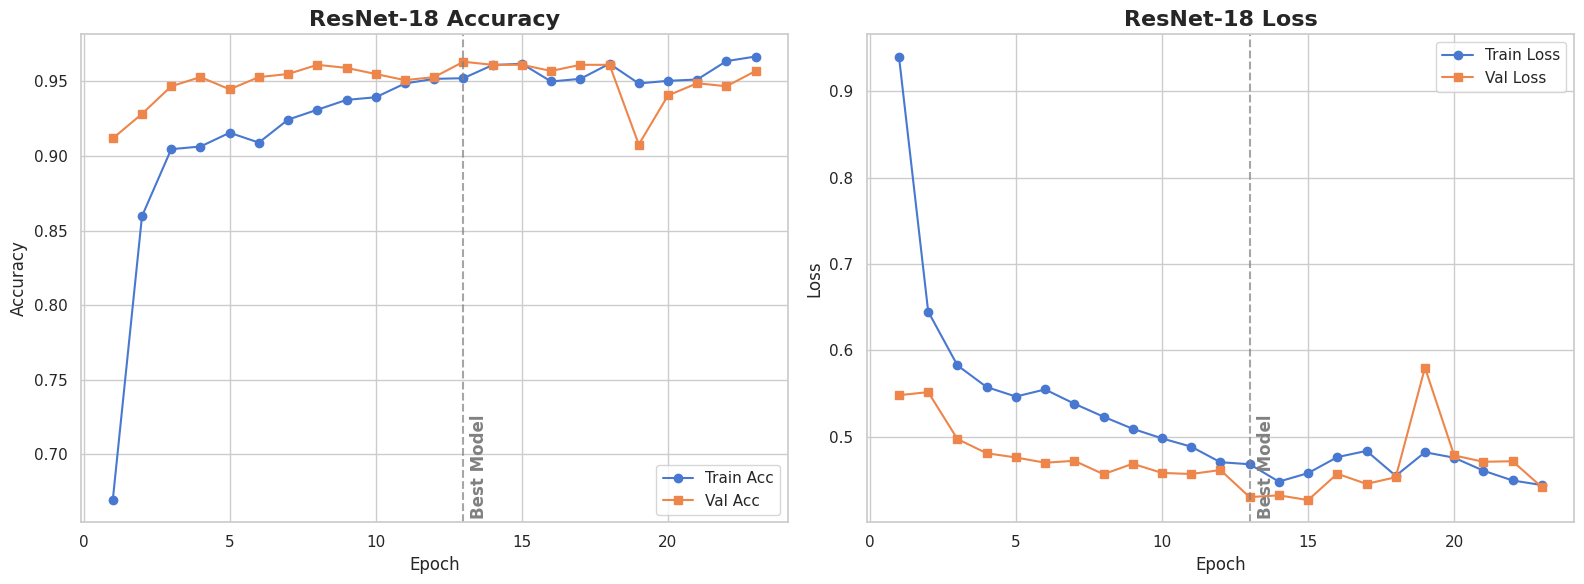

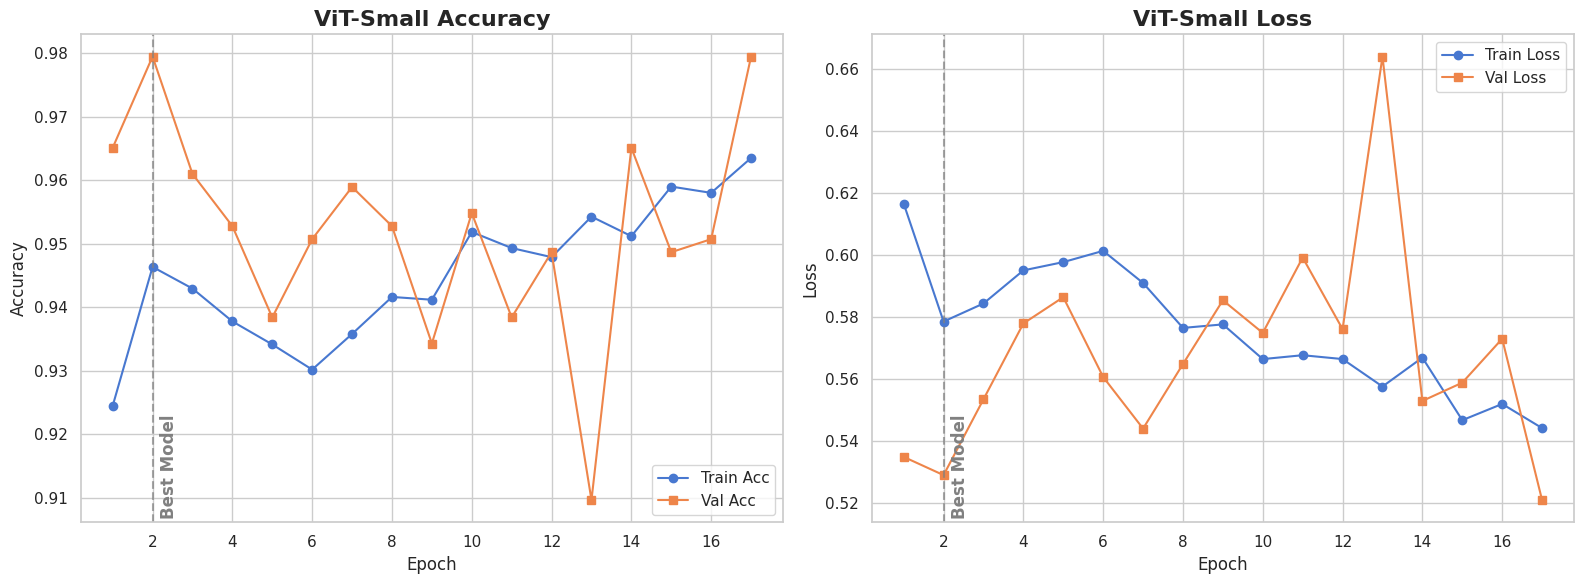

In [ ]:
def plot_detailed_history(history, model_name, save_prefix):
    epochs = range(1, len(history['train_loss']) + 1)

    # Accuracy & Loss side-by-side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Accuracy
    ax1.plot(epochs, history['train_acc'], 'o-', label='Train Acc')
    ax1.plot(epochs, history['val_acc'], 's-', label='Val Acc')
    ax1.set_title(f'{model_name} Accuracy', fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    # Loss
    ax2.plot(epochs, history['train_loss'], 'o-', label='Train Loss')
    ax2.plot(epochs, history['val_loss'], 's-', label='Val Loss')
    ax2.set_title(f'{model_name} Loss', fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    # Mark Early Stopping (Best Val Acc usually corresponds to the saved checkpoint)
    best_epoch = np.argmax(history['val_acc']) + 1
    for ax in [ax1, ax2]:
        ax.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.7)
        ax.annotate('Best Model', xy=(best_epoch, ax.get_ylim()[0]), xytext=(5, 5),
                    textcoords='offset points', rotation=90, color='gray', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f"{DRIVE_PATH}/plots/{save_prefix}_detailed_curves.png", dpi=300)
    plt.show()

# Note: This assumes history objects from previous cells exist.
if 'history_resnet' in locals():
    plot_detailed_history(history_resnet, "ResNet-18", "resnet18")
if 'history_vit' in locals():
    plot_detailed_history(history_vit, "ViT-Small", "vit")

Generating per-class comparison charts...


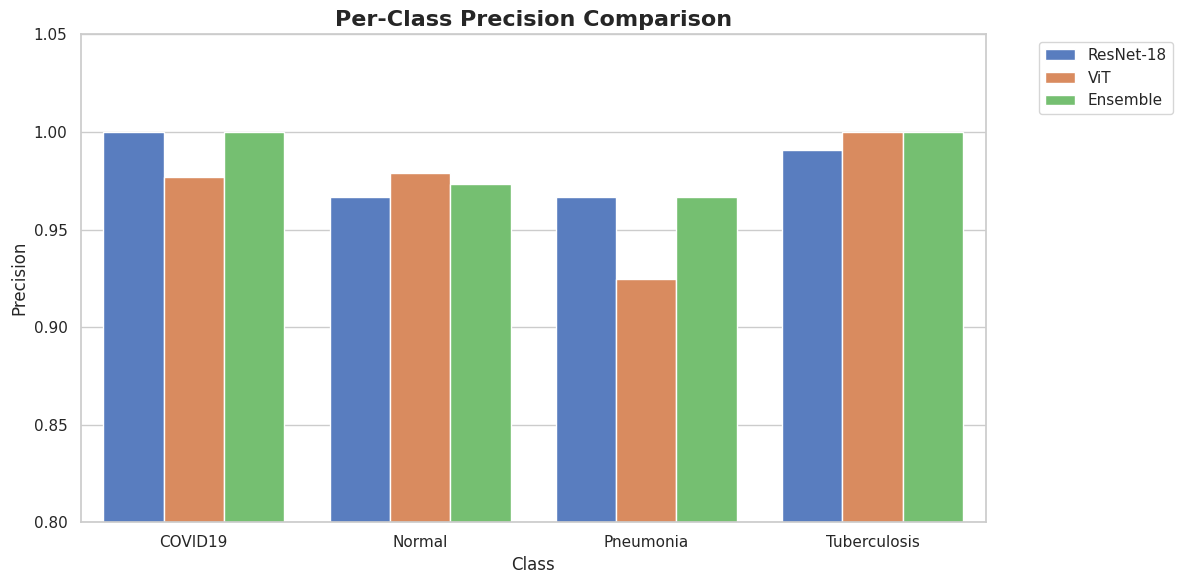

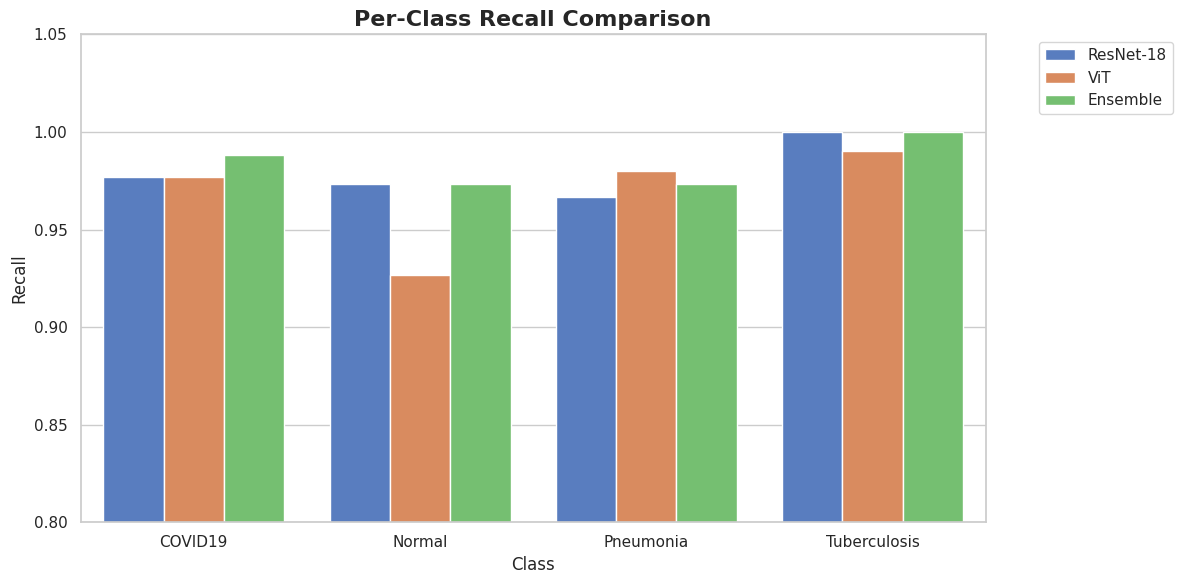

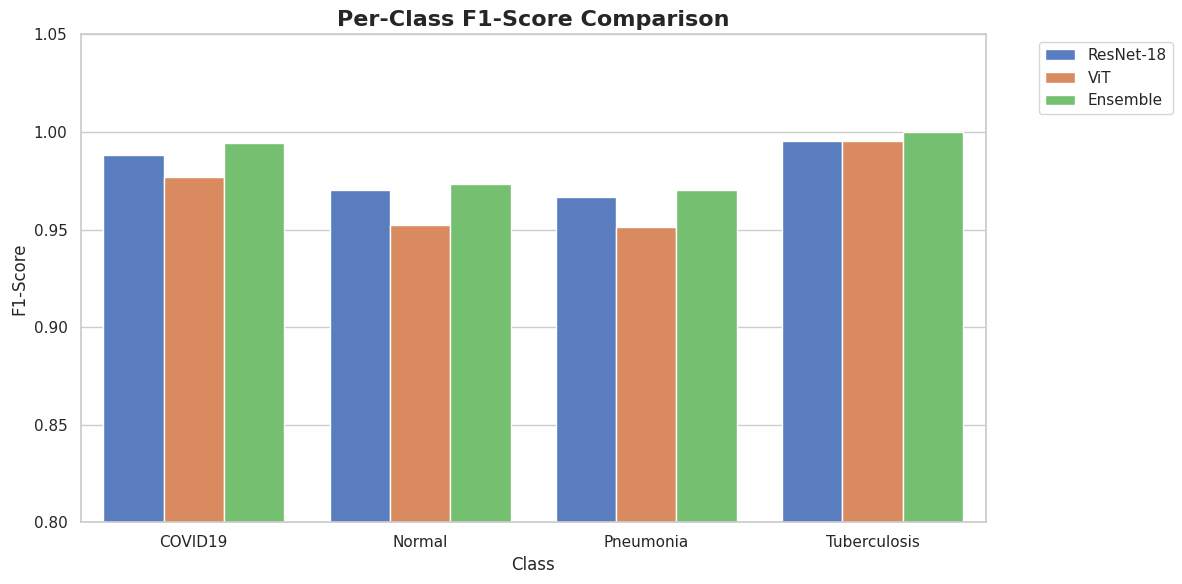

In [ ]:
# --- 3. Per-Class Metrics Comparison Bar Chart ---
print("Generating per-class comparison charts...")

def get_metrics_df(results, name):
    return pd.DataFrame({
        'Class': results['class_names'],
        'Precision': results['precision'],
        'Recall': results['recall'],
        'F1-Score': results['f1'],
        'Model': name
    })

# Collecting data from previous evaluation results
dfs = []
if 'results_resnet' in locals(): dfs.append(get_metrics_df(results_resnet, 'ResNet-18'))
if 'results_vit' in locals(): dfs.append(get_metrics_df(results_vit, 'ViT'))
if 'results_ensemble' in locals(): dfs.append(get_metrics_df(results_ensemble, 'Ensemble'))

if dfs:
    df_all_metrics = pd.concat(dfs)

    for metric in ['Precision', 'Recall', 'F1-Score']:
        plt.figure(figsize=(12, 6))
        sns.barplot(data=df_all_metrics, x='Class', y=metric, hue='Model')
        plt.title(f"Per-Class {metric} Comparison", fontweight='bold')
        plt.ylim(0.8, 1.05) # Zoom in on high performance range
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig(f"{DRIVE_PATH}/plots/comparison_{metric.lower()}.png", dpi=300)
        plt.show()

### 🎯 Final Model Comparison & Confusion Matrices

This section generates the final high-resolution comparison charts and confusion matrices for the project report.

Generating normalized confusion matrices...


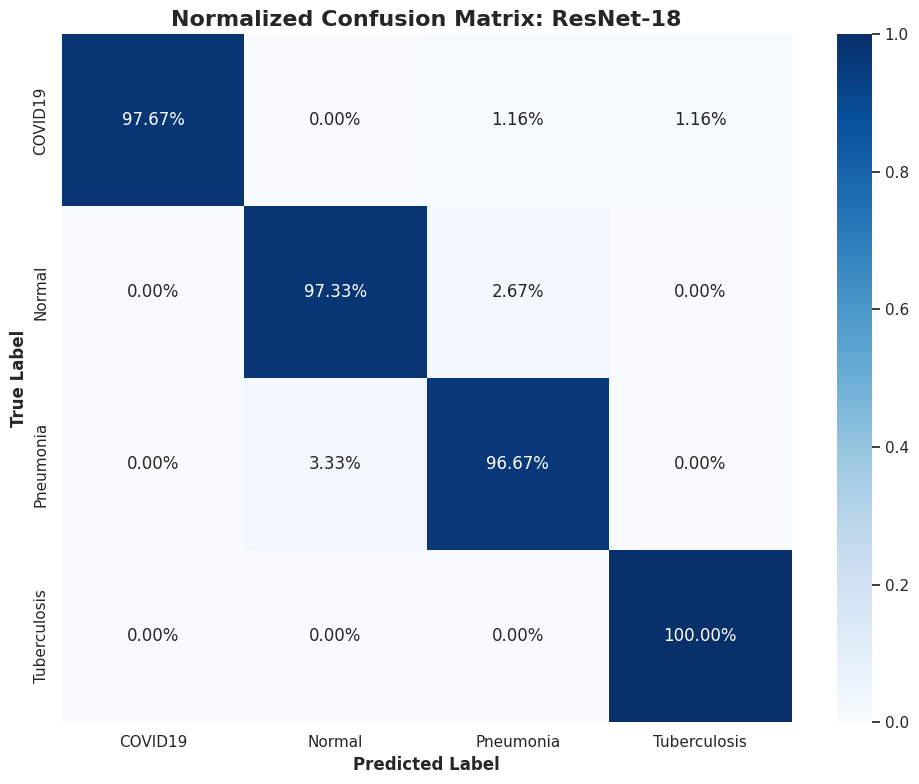

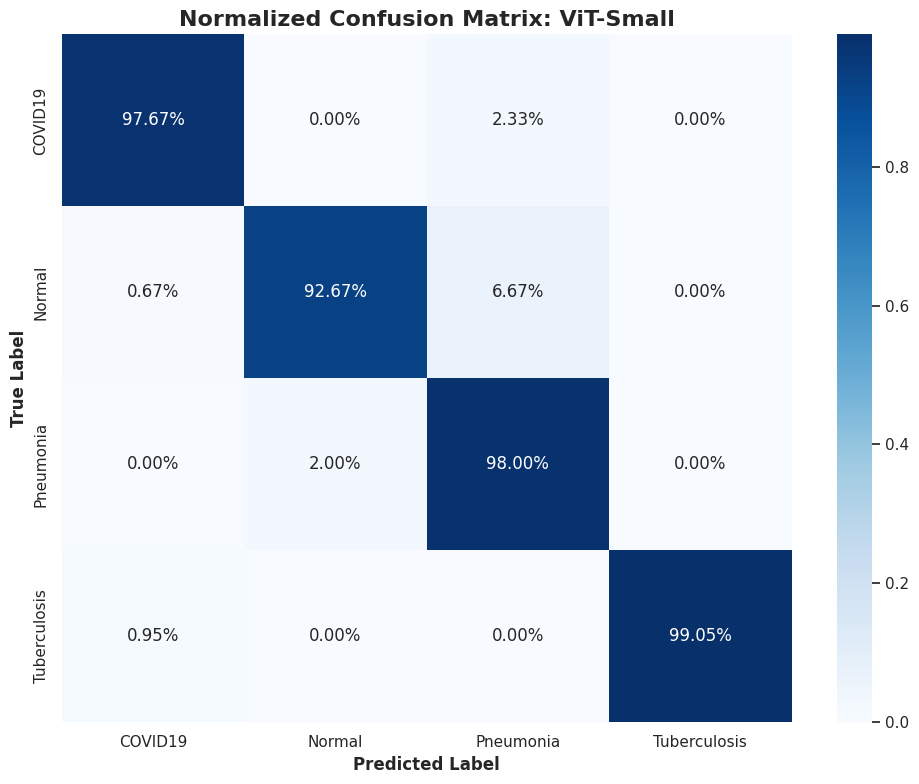

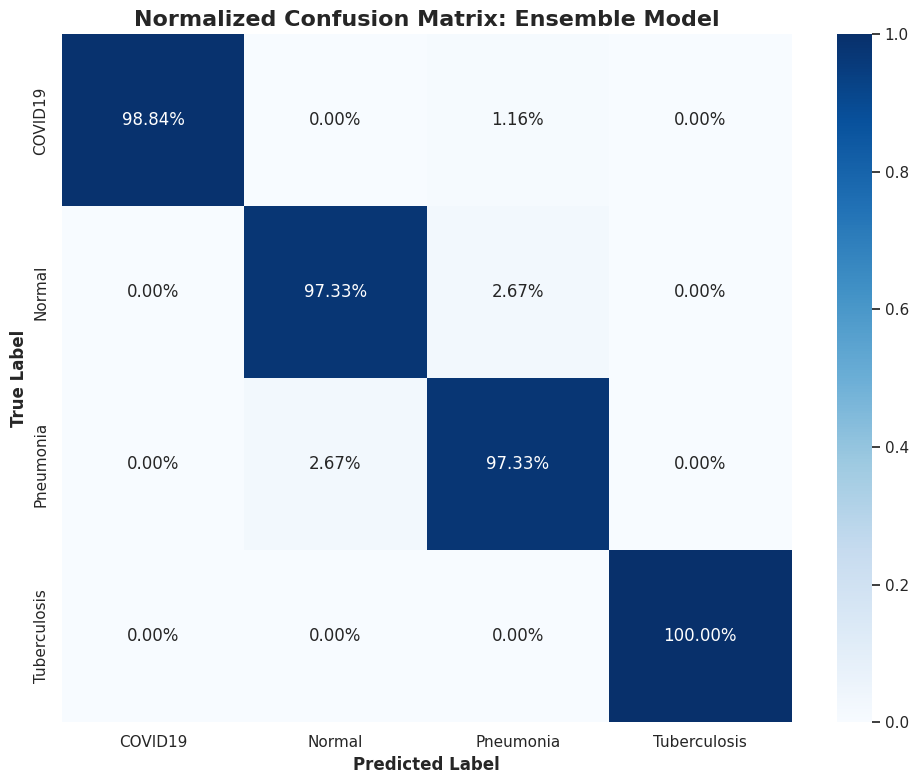

In [ ]:
# --- 4. Normalized Confusion Matrices (ResNet, ViT, Ensemble) ---
print("Generating normalized confusion matrices...")

def plot_normalized_cm(y_true, y_pred, class_names, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Normalized Confusion Matrix: {title}", fontweight='bold')
    plt.ylabel('True Label', fontweight='bold')
    plt.xlabel('Predicted Label', fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# ResNet-18 CM
if 'y_true_resnet' in locals():
    plot_normalized_cm(y_true_resnet, y_pred_resnet, class_names, "ResNet-18", f"{DRIVE_PATH}/plots/resnet18_cm_normalized.png")

# ViT CM
if 'y_true_vit' in locals():
    plot_normalized_cm(y_true_vit, y_pred_vit, class_names, "ViT-Small", f"{DRIVE_PATH}/plots/vit_cm_normalized.png")

# Ensemble CM
if 'best_y_true_ens' in locals():
    plot_normalized_cm(best_y_true_ens, best_y_pred_ens, class_names, "Ensemble Model", f"{DRIVE_PATH}/plots/ensemble_cm_normalized.png")

Generating final accuracy comparison...


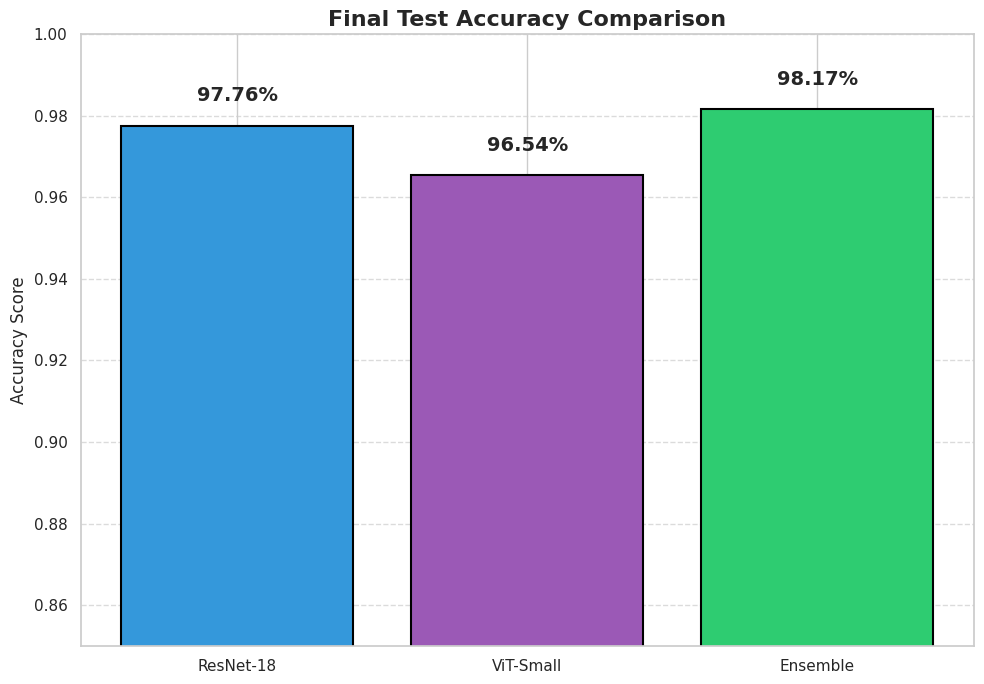

🎉 All visualizations requested for the report have been generated and saved to Drive.


In [ ]:
# --- 5. Accuracy Comparison Bar Chart ---
print("Generating final accuracy comparison...")

model_names = []
accuracies = []

if 'acc_resnet' in locals():
    model_names.append('ResNet-18')
    accuracies.append(acc_resnet)
if 'acc_vit' in locals():
    model_names.append('ViT-Small')
    accuracies.append(acc_vit)
if 'best_ensemble_acc' in locals():
    model_names.append('Ensemble')
    accuracies.append(best_ensemble_acc)

plt.figure(figsize=(10, 7))
colors = ['#3498db', '#9b59b6', '#2ecc71']
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', linewidth=1.5)

# Label exact values
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=14)

plt.title("Final Test Accuracy Comparison", fontweight='bold')
plt.ylabel("Accuracy Score")
plt.ylim(0.85, 1.0) # Zoom in to highlight differences
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f"{DRIVE_PATH}/plots/final_accuracy_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print("🎉 All visualizations requested for the report have been generated and saved to Drive.")

## Backend Integration (FastAPI)

In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms, models
import timm
from PIL import Image
import io
import numpy as np
import json

# --- Configuration --- #
# This path should point to where your models and results are saved
# Ensure your FastAPI server has access to this path.
DRIVE_PATH = '/content/drive/MyDrive/ChestXray_Project_X' # Update if running locally

# Ensure `class_names` are defined as they were during training
# You can load this from the saved results JSON if needed, or hardcode if stable.
class_names = ["COVID19", "Normal", "Pneumonia", "Tuberculosis"]
num_classes = len(class_names)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. Define Model Architectures (as they were trained) ---

# ResNet Model Definition
class AdvancedResNet(nn.Module):
    def __init__(self, num_classes, dropout=0.5):
        super().__init__()
        self.backbone = models.resnet18(pretrained=False) # Set to False as we load weights
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(p=dropout * 0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

# Ensemble Model Definition (similar to the one in the notebook)
class EnsembleModel(nn.Module):
    def __init__(self, resnet, vit, weights=[0.5, 0.5]):
        super().__init__()
        self.resnet = resnet
        self.vit = vit
        self.weights = torch.tensor(weights, device=device)
        # Set models to evaluation mode once loaded
        self.resnet.eval()
        self.vit.eval()

    def forward(self, x_resnet, x_vit):
        with torch.no_grad():
            resnet_out = torch.softmax(self.resnet(x_resnet), dim=1)
            vit_out = torch.softmax(self.vit(x_vit), dim=1)
            return self.weights[0] * resnet_out + self.weights[1] * vit_out


# --- 2. Load Saved Model Weights ---
print("Loading models...")

# Load ResNet
model_resnet = AdvancedResNet(num_classes=num_classes, dropout=0.5).to(device)
resnet_state_dict = torch.load(f"{DRIVE_PATH}/models/best_resnet18_advanced.pth", map_location=device)
model_resnet.load_state_dict(resnet_state_dict)
model_resnet.eval()
print("✅ ResNet-18 model loaded.")

# Load ViT
model_vit = timm.create_model('vit_small_patch16_224', pretrained=False, num_classes=num_classes).to(device)
vit_state_dict = torch.load(f"{DRIVE_PATH}/models/best_vit_advanced.pth", map_location=device)
model_vit.load_state_dict(vit_state_dict)
model_vit.eval()
print("✅ ViT model loaded.")

# Load ensemble weights (assuming you saved them or use the best one found)
# You can get `best_weights` from `ensemble_results.json` if available
with open(f"{DRIVE_PATH}/results/ensemble_results.json", 'r') as f:
    ensemble_results = json.load(f)
best_weights = [ensemble_results['weights']['resnet'], ensemble_results['weights']['vit']]

ensemble_model = EnsembleModel(model_resnet, model_vit, weights=best_weights).to(device)
print(f"✅ Ensemble model loaded with weights: ResNet={best_weights[0]}, ViT={best_weights[1]}.")

print("All models successfully loaded!")


# --- 3. Image Preprocessing Pipelines ---

# ResNet preprocessing (same as val_test_transforms)
transform_resnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ViT preprocessing (same as val_test_transforms_vit)
transform_vit = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


# --- 4. Prediction Function ---
def predict_image(image_bytes: bytes):
    image = Image.open(io.BytesIO(image_bytes)).convert('RGB')

    # Preprocess for ResNet
    input_resnet = transform_resnet(image).unsqueeze(0).to(device)

    # Preprocess for ViT
    input_vit = transform_vit(image).unsqueeze(0).to(device)

    # Get ensemble predictions
    with torch.no_grad():
        outputs = ensemble_model(input_resnet, input_vit)
        probabilities = torch.softmax(outputs, dim=1)[0].cpu().numpy()

    # Map probabilities to class names
    predictions = {class_name: float(prob) for class_name, prob in zip(class_names, probabilities)}
    return predictions

print("Prediction function ready.")

Now, here's how you can set up a simple FastAPI application (`main.py`) to use this prediction function. You would run this Python file as a server (e.g., `uvicorn main:app --reload`).

In [ ]:
# from fastapi import FastAPI, UploadFile, File
# from fastapi.responses import JSONResponse
# from typing import Dict
# # Assume the model loading and predict_image function are in the same file or imported
# # from your_model_module import predict_image

# app = FastAPI(
#     title="Chest X-ray Classification API",
#     description="API for classifying Chest X-ray images into Normal, Pneumonia, COVID19, and Tuberculosis using an ensemble deep learning model."
# )

# @app.get("/", response_class=JSONResponse)
# async def read_root():
#     return {"message": "Welcome to the Chest X-ray Classification API!"}

# @app.post("/predict/", response_model=Dict[str, float])
# async def predict_xray(file: UploadFile = File(...)):
#     """
#     Upload a Chest X-ray image (JPEG, PNG) and get confidence scores
#     for different lung conditions (Normal, Pneumonia, COVID19, Tuberculosis).
#     """
#     if not file.content_type.startswith(('image/jpeg', 'image/png')):
#         return JSONResponse(status_code=400, content={"detail": "Invalid file type. Only JPEG and PNG images are supported."})

#     try:
#         image_bytes = await file.read()
#         predictions = predict_image(image_bytes)
#         return JSONResponse(content=predictions)
#     except Exception as e:
#         return JSONResponse(status_code=500, content={"detail": f"Prediction failed: {str(e)}"})


# # To run this FastAPI app locally, save the above code (and the model loading/predict_image code) as `main.py`
# # and then execute: `uvicorn main:app --reload` in your terminal.
# # You would typically run this on a server or a machine with GPU access for performance.


### Add Grad-CAM Visualization

First, install the `pytorch-gradcam` library.

In [ ]:
# pip install -q pytorch-gradcam

Now, let's define a function to generate and overlay the Grad-CAM heatmap. We'll use the `model_resnet` as an example here, but you could adapt it for `model_vit` or even explore ensemble-based Grad-CAM approaches.

For ResNet-18, a good target layer for Grad-CAM is often the last convolutional layer before the global average pooling, such as `model_resnet.backbone.layer4`.

In [ ]:
# from pytorch_grad_cam import GradCAM
# from pytorch_grad_cam.utils.image import show_cam_on_image
# from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# def generate_gradcam_image(image_bytes: bytes, model, target_layer, transform_func, class_names, top_k_class_idx=None):
#     image = Image.open(io.BytesIO(image_bytes)).convert('RGB')
#     rgb_img = np.array(image) / 255.0 # For overlaying

#     input_tensor = transform_func(image).unsqueeze(0).to(device)

#     # Construct the GradCAM object. Use the target layer from the model.
#     cam = GradCAM(model=model, target_layers=[target_layer], use_cuda=torch.cuda.is_available())

#     # If a specific class index is provided (e.g., the predicted class), use it.
#     # Otherwise, Grad-CAM will generate for the highest scoring class.
#     targets = None
#     if top_k_class_idx is not None:
#         targets = [ClassifierOutputTarget(top_k_class_idx)]

#     # You can also pass aug_smooth=True and eigen_smooth=True, as in the Grad-CAM tutorials
#     grayscale_cam = cam(input_tensor=input_tensor, targets=targets, aug_smooth=True, eigen_smooth=True)

#     # In this example, the cam is converted to grayscale and then to 3 channels.
#     # We will use the first image in the batch (index 0).
#     grayscale_cam = grayscale_cam[0, :]

#     # Overlay the CAM on the original image
#     cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

#     # Convert numpy array to PIL Image for easy return/saving
#     cam_pil_image = Image.fromarray((cam_image * 255).astype(np.uint8))

#     return cam_pil_image

# print("Grad-CAM utility function ready.")

### 🔍 Explainability: Grad-CAM Visualizations

This section generates Grad-CAM heatmaps for representative samples of each class to visualize model focus. Images are saved with predicted labels and confidence scores.

In [ ]:
# import cv2
# import numpy as np
# from pytorch_grad_cam import GradCAM
# from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
# from pytorch_grad_cam.utils.image import show_cam_on_image

# print("Generating Grad-CAM visualizations...")

# # Initialize Grad-CAM for ResNet-18
# target_layers = [model_resnet.backbone.layer4]
# cam = GradCAM(model=model_resnet, target_layers=target_layers)

# fig, axes = plt.subplots(1, 4, figsize=(20, 6))
# plt.style.use('seaborn-v0_8-whitegrid')

# for i, cls in enumerate(class_names):
#     # Get a random image from the test set for this class
#     class_path = f"{DRIVE_PATH}/dataset/test/{cls}"
#     img_name = random.choice([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
#     img_path = os.path.join(class_path, img_name)

#     # Load and preprocess
#     raw_img = Image.open(img_path).convert('RGB')
#     input_tensor = transform_resnet(raw_img).unsqueeze(0).to(device)

#     # Get prediction
#     with torch.no_grad():
#         output = model_resnet(input_tensor)
#         probs = torch.softmax(output, dim=1)
#         conf, pred_idx = torch.max(probs, 1)
#         pred_label = class_names[pred_idx.item()]
#         confidence = conf.item() * 100

#     # Generate CAM
#     grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(pred_idx.item())])[0, :]
#     rgb_img = np.array(raw_img.resize((224, 224))) / 255.0
#     visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

#     # Plot
#     axes[i].imshow(visualization)
#     axes[i].set_title(f"True: {cls}\nPred: {pred_label} ({confidence:.1f}%)", fontsize=12, fontweight='bold')
#     axes[i].axis('off')

# plt.suptitle("Grad-CAM Heatmaps (ResNet-18 Backbone)", fontsize=18, fontweight='bold', y=1.05)
# plt.tight_layout()
# plt.savefig(f"{DRIVE_PATH}/plots/gradcam_explainability_grid.png", dpi=300, bbox_inches='tight')
# plt.show()
# print(f"✅ Grad-CAM grid saved to {DRIVE_PATH}/plots/gradcam_explainability_grid.png")

### How to use it with your FastAPI app

To integrate this into your FastAPI application, you would modify your `main.py`:

1.  **Add a new endpoint** (e.g., `/predict_with_cam/`) or modify the existing `/predict/` endpoint.
2.  **Call `predict_image`** first to get the class predictions.
3.  **Determine the target class for Grad-CAM**: You might want to generate Grad-CAM for the predicted class (the one with the highest confidence) or for a specific class that the user requests.
4.  **Call `generate_gradcam_image`** with the appropriate model (e.g., `model_resnet`), its target layer (`model_resnet.backbone.layer4`), the image bytes, and the predicted class index.
5.  **Return the Grad-CAM image:** Convert the `cam_pil_image` to bytes (e.g., JPEG or PNG) and return it in the response, perhaps along with the original predictions.

**Example modification for `main.py` (Hypothetical endpoint):**

```python
# ... existing imports and model loading ...

from fastapi.responses import Response
import base64

# ... (Paste the AdvancedResNet class, EnsembleModel class, and the predict_image function here)

# Assuming model_resnet, model_vit, ensemble_model, transform_resnet, transform_vit, class_names, device are all defined from the previous cell.

@app.post("/predict_with_cam/")
async def predict_xray_with_cam(file: UploadFile = File(...)): # Change endpoint name
    if not file.content_type.startswith(('image/jpeg', 'image/png')):
        return JSONResponse(status_code=400, content={"detail": "Invalid file type. Only JPEG and PNG images are supported."})

    try:
        image_bytes = await file.read()
        
        # Get predictions first
        predictions = predict_image(image_bytes)
        
        # Find the predicted class index for Grad-CAM
        predicted_class_name = max(predictions, key=predictions.get)
        predicted_class_idx = class_names.index(predicted_class_name)

        # Generate Grad-CAM for the predicted class using the ResNet model
        cam_image_pil = generate_gradcam_image(
            image_bytes=image_bytes,
            model=model_resnet, # Using ResNet for CAM, you could use ViT or other logic
            target_layer=model_resnet.backbone.layer4, # Specific to ResNet-18
            transform_func=transform_resnet,
            class_names=class_names,
            top_k_class_idx=predicted_class_idx
        )

        # Convert CAM image to bytes
        img_byte_arr = io.BytesIO()
        cam_image_pil.save(img_byte_arr, format='PNG') # Or JPEG
        img_byte_arr = img_byte_arr.getvalue()

        # Return both predictions and the base64 encoded CAM image
        return JSONResponse(content={
            "predictions": predictions,
            "cam_image_png": base64.b64encode(img_byte_arr).decode('utf-8')
        })

    except Exception as e:
        return JSONResponse(status_code=500, content={"detail": f"Prediction or CAM generation failed: {str(e)}"})

print("FastAPI endpoint idea for Grad-CAM added. Remember to put this in your main.py.")
```

**Note:** When using Grad-CAM with the `EnsembleModel`, you would typically apply Grad-CAM to one of the constituent models (like `model_resnet` or `model_vit`) as the `EnsembleModel` itself doesn't have a single convolutional layer to target. You might choose the model that contributes most heavily, or generate a CAM for each and combine them on the frontend.